# Исследование рынка общественного питания Москвы
## Цель и задачи

**Цель:**
Провести исследовательский анализ рынка общественного питания Москвы, чтобы определить перспективные направления для открытия нового заведения и выявить закономерности между характеристиками заведений (формат, район, ценовой сегмент, рейтинг, масштаб), которые помогут заказчику принять обоснованное решение.

Особое внимание в исследовании уделяется выявлению взаимосвязей и корреляций между ценами, рейтингом, типом заведения, количеством посадочных мест и расположением, поскольку инвесторы ещё не определили формат, ценовую политику и район размещения будущего бизнеса.

**Задачи:**

1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:

  - изучить структуру рынка общественного питания Москвы;

  - проанализировать распределение заведений по категориям и административным округам;

  - изучить ценовой сегмент рынка;

  - исследовать взаимосвязь рейтинга, цен, категории и масштаба заведений;

  - оценить уровень конкуренции в различных округах.

4. Сформулировать выводы и подготовить рекомендации для инвесторов.


## Данные

Для анализа поступили данные о заведениях общественного питания Москвы.
Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;

- `rest_price.csv` — информация о ценовом сегменте заведений.

###  Описание датасета rest_info

- `id` — идентификатор заведения;

- `name` — название заведения;

- `address` — адрес заведения;

- `district` — административный округ, в котором находится заведение;

- `category` — категория заведения (кафе, ресторан, кофейня и др.);

- `hours` — дни и часы работы;

- `rating` — рейтинг заведения по данным Яндекс Карт (максимум — 5.0);

- `chain` — является ли заведение сетевым:

  - 0 — не является сетевым;

  - 1 — является сетевым;

- `seats` — количество посадочных мест.

###  Описание датасета rest_price

- `id` — идентификатор заведения;

- `price` — категория цен (низкие, средние, выше среднего и т.д.);

- `avg_bill` — текстовая информация о среднем чеке (например: «Средний счёт: 1000–1500 ₽»);

- `middle_avg_bill` — числовая оценка среднего чека (медиана диапазона);

- `middle_coffee_cup` — числовая оценка стоимости чашки капучино.

## Содержимое проекта

1. [Загрузка данных и знакомство с ними](#chapter1)
2. [Предобработка данных](#chapter2)
    * 2.1. [Преобразование типов данных](#chapter2.1)
    * 2.2. [Проверяем наличие пропусков в данных](#chapter2.2)
    * 2.3. [Поиск и удаление дубликатов¶](#chapter2.3)
    * 2.4. [Промежуточный вывод. Предобработка данных](#chapter2.4)
3. [Исследовательский анализ данных](#chapter3)
    * 3.1. [Количество объектов общественного питания по категориям](#chapter3.1)
    * 3.2. [Распределение объектов общественного питания по районам](#chapter3.2)
    * 3.3. [Соотношение сетевых и несетевых заведений](#chapter3.3)
    * 3.4. [Распределение посадочных мест по типам заведений](#chapter3.4)
    * 3.5. [Распределение рейтинга заведений по их категориям](#chapter3.5)
    * 3.6. [Взаимосвязь рейтинга с характеристиками заведения](#chapter3.6)
    * 3.7. [Топ-15 популярных сетей в Москве](#chapter3.7)
    * 3.8. [Анализ среднего чека в зависимости от района и удалённости от центра](#chapter3.8)
4. [Итоговый вывод и рекомендации](#chapter4)     

<a id='chapter1'></a>
## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `rest_info.csv` и `rest_price.csv`. Будем использовать `pandas` и библиотеки визуализации данных `matplotlib` и `seaborn`, а также `phik` для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `rest_info` и `rest_price`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install phik
# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем CSV-файлы в датафреймы
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
# Выводим первые строки датафрейма
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
# Рассчитаем процента пропусков с сортировкой от большего к меньшему
(rest_info.isna().sum() / len(rest_info) * 100).sort_values(ascending=False).round(2)

seats       42.96
hours        6.38
id           0.00
name         0.00
category     0.00
address      0.00
district     0.00
rating       0.00
chain        0.00
dtype: float64

Датасет `rest_info.csv` содержит **9 столбцов и 8406 строк** с информацией о заведениях общественного питания (название, категория, адрес, округ, часы работы, рейтинг, сетевой статус, количество мест).

После первичного анализа данных можно сделать следующие выводы:
- Структура столбцов соответствует описанию в задании.
- **Типы данных**: численные признаки хранятся в форматах `int64` или `float64`. Значения в столбце `seats` имеют тип с плавающей точкой, а `chain` — целочисленный бинарный признак (0 и 1). Размерность этих данных можно оптимизировать для экономии памяти.
- Столбец `id` является техническим идентификатором заведения, используется для объединения таблиц и пропусков не имеет.
- **Пропущенные значения**: обнаружены пропуски, в частности в столбце `seats`. Требуется дополнительная проверка остальных столбцов на наличие скрытых пропусков и аномалий.
- **Обработка признаков**: столбец `hours` содержит текстовое описание графика работы в разных форматах, что потребует обработки перед анализом. Также необходимо проверить единообразие категорий в `category` и корректность диапазонов в `rating` и `seats`.
- **Единообразие**: столбцы `name`, `address` и `district` целесообразно привести к нижнему регистру для корректного поиска дубликатов и удобства группировки. 

В целом данные соответствуют описанию и пригодны для проведения дальнейшего исследовательского анализа рынка.
Познакомимся с данными датасета `rest_price.csv`:

In [7]:
# Выводим первые строки датафрейма на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [8]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [9]:
# Рассчитаем процент пропусков с сортировкой от большего к меньшему
(rest_price.isna().sum() / len(rest_price) * 100).sort_values(ascending=False).round(2)

middle_coffee_cup    86.82
middle_avg_bill      22.40
price                18.31
avg_bill              5.96
id                    0.00
dtype: float64

Датасет `rest_price.csv` содержит **5 столбцов и 4058 строк** с информацией о ценовой категории заведений и среднем чеке.

После первичного анализа можно сделать следующие выводы:

- **Типы данных заданы корректно**: `price` и `avg_bill` — строковые признаки; `middle_avg_bill` и `middle_coffee_cup` — числовые (`float64`), что удобно для дальнейшего анализа.
- **Столбец id** является техническим идентификатором заведения, используется для объединения таблиц и не имеет пропусков.
- **В данных присутствуют пропуски**:
  - `middle_coffee_cup` — около **87%**. Высокая доля пропусков, скорее всего, связана с тем, что числовые столбцы заполняются только при наличии соответствующей текстовой информации.
  - `middle_avg_bill` — около **22%**;
  - `price` — около **18%**;
  - `avg_bill` — около **6%**.
- **Выбор целевого признака**: столбец `avg_bill` содержит исходное текстовое описание (диапазон или одно значение), а `middle_avg_bill` — числовую медиану. Для анализа среднего чека целесообразно использовать именно `middle_avg_bill`, так как он уже приведен к числовому формату.

В целом данные соответствуют описанию и пригодны для анализа, но требуют аккуратной работы с пропусками и проверки взаимосвязи ценовых показателей. Стиль заголовков столбцов унифицирован и не требует изменений.

Для дальнейшего анализа **объединим таблицы** `rest_info` и `rest_price` по идентификатору заведения `id`.

Используем `left join`, чтобы сохранить все заведения из `rest_info` (**8406 записей**)

и добавить ценовую информацию там, где она представлена:

In [10]:
rest_full = rest_info.merge(rest_price, on='id', how='left')

In [11]:
# Проверяем размер итогового датафрейма
rest_full.shape

(8406, 13)

<a id='chapter2'></a>
## 2. Предобработка данных

<a id='chapter2.1'></a>
### 2.1. Преобразование типов данных

In [12]:
# Выводим информацию о датафрейме rest_full
rest_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [13]:
# Оптимизируем целочисленный тип данных в датафрейме rest_full
#chain 
rest_full['chain'] = pd.to_numeric(rest_full['chain'],
                                   downcast='integer')
# seats
rest_full['seats'] = rest_full['seats'].astype('Int16')

In [14]:
# Проверяем типы данных
rest_full.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   int8
seats                  Int16
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Типы данных были успешно оптимизированы с понижением размерности целочисленных данных.

<a id='chapter2.2'></a>
### 2.2. Проверяем наличие пропусков в данных

При первичном анализе мы обнаружили пропуски в столбцах `middle_coffee_cup`, `middle_avg_bill`, `price`, `avg_bill`, `seats`, `hours`. Рассчитаем количество и долю пропущенных значений в датафрейме `rest_full`, чтобы оценить масштаб неполных данных.

In [15]:
# Применяем метод isna() к датафрейму
rest_full.isna().sum().sort_values(ascending=False)

middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
dtype: int64

In [16]:
# Подсчитываем долю строк с пропусками
rest_full.isna().mean().sort_values(ascending=False)

middle_coffee_cup    0.936355
middle_avg_bill      0.625387
price                0.605639
avg_bill             0.546039
seats                0.429574
hours                0.063764
id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
rating               0.000000
chain                0.000000
dtype: float64

После объединения таблиц количество строк соответствует числу заведений в `rest_info`. При этом доля пропусков в ценовых показателях обусловлена тем, что информация о ценах представлена не для всех заведений в исходном датасете `rest_price`.

Таким образом, пропуски в столбцах `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup`, `seats` являются результатом объединения таблиц и носят структурный характер.

Заполнять пропуски средними или медианными значениями нецелесообразно, поскольку это приведёт к искажению реальной картины рынка и искусственно выровняет ценовые различия между заведениями. Также некорректно удалять строки с пропусками, так как это приведёт к потере информации о самих заведениях.

Анализ ценовых характеристик будет проводиться на подвыборках заведений, для которых соответствующие данные представлены.

#### Проверим столбец `middle_coffee_cup`, 
который имеет ~93% пропусков. 
Пропуски могут быть связан с тем, что показатель актуален только для кофеен/кафе.
Изучим уникальные значения в столбце `avg_bill` и посмотрим, можно ли использовать их для заполнения `middle_coffee_cup`, или же данные в этих столбцах уже совпадают:

In [17]:
# Выводим уникальные значения
rest_full['avg_bill'].unique()

array([nan, 'Средний счёт:1500–1600 ₽', 'Средний счёт:от 1000 ₽',
       'Цена чашки капучино:155–185 ₽', 'Средний счёт:400–600 ₽',
       'Средний счёт:199 ₽', 'Средний счёт:200–300 ₽',
       'Средний счёт:от 500 ₽', 'Средний счёт:1000–1200 ₽',
       'Цена бокала пива:250–350 ₽', 'Средний счёт:330 ₽',
       'Средний счёт:1500 ₽', 'Средний счёт:300–500 ₽',
       'Средний счёт:140–350 ₽', 'Средний счёт:350–500 ₽',
       'Средний счёт:300–1500 ₽', 'Средний счёт:от 240 ₽',
       'Средний счёт:200–250 ₽', 'Средний счёт:328 ₽',
       'Средний счёт:300 ₽', 'Средний счёт:от 345 ₽',
       'Средний счёт:60–400 ₽', 'Средний счёт:900 ₽',
       'Средний счёт:500–800 ₽', 'Средний счёт:500–1000 ₽',
       'Средний счёт:600–700 ₽', 'Цена бокала пива:120–350 ₽',
       'Средний счёт:1000–1500 ₽', 'Средний счёт:1500–2000 ₽',
       'Цена чашки капучино:150–190 ₽', 'Средний счёт:2000–2500 ₽',
       'Средний счёт:600 ₽', 'Средний счёт:450 ₽',
       'Цена чашки капучино:120–170 ₽', 'Средний счё

In [18]:
# Считаем количество заполненных (непустых) значений
rest_full['middle_coffee_cup'].notna().sum()

535

In [19]:
# Создаем маску для поиска строк, где упоминается «капучино» (регистронезависимо)
coffee_mask = rest_full['avg_bill'].str.contains('капучино', case=False, na=False)

# Извлекаем числовые значения цены и вычисляем среднее для каждой строки
extracted = (
    rest_full.loc[coffee_mask, 'avg_bill']
    # Извлекаем одну или две группы цифр
    .str.extract(r'(\d+)[–-]?(\d+)?')
    # Приводим к типу float для математических операций
    .astype(float)
    # Считаем среднее по строке: (min + max) / 2 или просто значение, если число одно
    .mean(axis=1)
)
# Считаем количество успешно извлеченных значений
extracted_count = extracted.count()


display(f"Количество извлеченных значений: {extracted_count}")

'Количество извлеченных значений: 535'

Данные в этих столбцах уже совпадают. 

Удалять столбец не будем, так как инвесторы еще не определились с форматом.
Пропуски оставляем без заполнения — будем анализировать показатель только в релевантных категориях.

Можно будет посмотреть ценовой сегмент кофейн.

#### Аналогичная проверку проведем для столбца `middle_avg_bill`:

In [20]:
# Считаем количество заполненных (непустых) значений
rest_full['middle_avg_bill'].notna().sum()

3149

In [21]:
# Создаем маску для поиска строк, где в тексте упоминается «средний чек»
middle_mask = rest_full['avg_bill'].str.contains('средний чек', case=False, na=False)

# Извлекаем числа и считаем среднее
extracted_avg = (
    rest_full.loc[middle_mask, 'avg_bill']
    .str.extract(r'(\d+)[–-]?(\d+)?')
    .astype(float)
    .mean(axis=1)
)

# Создаем проверочную таблицу (копию), чтобы увидеть расхождений
comparison = rest_full.loc[middle_mask, ['middle_avg_bill']].copy()
comparison['extracted_value'] = extracted_avg

# Считаем количество расхождений (включая заполнение пустых NaN значений)
diff_count = (comparison['middle_avg_bill'] != comparison['extracted_value']).sum()
display(f"Найдено расхождений/пропусков: {diff_count}")

# Итоговая проверка заполненности
print(f"Количество заполненных значений в middle_avg_bill: {rest_full['middle_avg_bill'].notna().sum()}")

'Найдено расхождений/пропусков: 0'

Количество заполненных значений в middle_avg_bill: 3149


Значения формируются из текстового столбца `avg_bill`, поэтому дублируют информацию в числовом формате. 

Существенных расхождений не обнаружено.

Пропусков слишком много 62,5%, оставим их как есть, чтобы не искажать реальную картину.



In [22]:
# Подсчитаем количество строк с нулевым значением среднего чека
(rest_full['middle_avg_bill'] == 0).sum()

1

Средний чек не может быть равен нулю в коммерческом заведении. Заменим значение на **NaN**.

In [23]:
# Заменим нулевые значения среднего чека на пропуски (NaN)
rest_full['middle_avg_bill'] = rest_full['middle_avg_bill'].replace(0, pd.NA)

Для корректного статистического анализа приведем столбец `middle_avg_bill` к числовому типу, преобразовав невалидные текстовые значения в пропуски (NaN):

In [24]:
# Преобразуем в числовой тип
rest_full['middle_avg_bill'] = pd.to_numeric(rest_full['middle_avg_bill'], errors='coerce')

####  Пропуски в столбце `seats`**:

Почти 43% — это серьезный объем данных.

Было принято решение оставить пропуски в столбце `seats` во избежание:
- **Потери репрезентативности**: удаление 43% данных лишит нас почти половины рынка Москвы, что сделает выводы для инвесторов неточными.
- **Искажения структуры данных**: пропуски часто встречаются у небольших заведений. Их удаление искусственно «раздует» долю крупных ресторанов и скроет целые ниши (например, стрит-фуд).
- **Смещения аналитики**: сохранение этих строк позволяет полноценно изучить другие важные параметры — географию и популярность форматов заведений.

*В рамках дополнительного анализа была протестирована гипотеза заполнения пропусков медианой по категории и признаку сетевого заведения. Результат анализа можно посмотреть в [разделе 3.4](#my_target)*

In [25]:
# Посмотрим описательную статистики
rest_full['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [26]:
# Посчитаем количества заведений с 0 посадочных мест для каждой категории
rest_full[rest_full['seats'] == 0]['category'].value_counts()

кафе               44
кофейня            24
ресторан           20
быстрое питание    18
булочная           11
пиццерия           10
столовая            5
бар,паб             4
Name: category, dtype: int64

Для категорий: "кофейня", "быстрое питание", "булочная" - нулевые посадочные места могут быть логичны (формат "на вынос").

Но для категорий "ресторан", "кафе", "столовая", "пиццерия", "бар,паб" - 0 мест выглядит подозрительно.

С высокой вероятностью - это пропущенные данные, которые не были указаны, либо техническая ошибка выгрузки.

In [27]:
# Заменяем нулевое количество мест на пропуски (NaN)
mask = (
    rest_full['category'].isin(['ресторан', 'кафе', 'столовая', 'пиццерия', 'бар,паб']) &
    (rest_full['seats'] == 0)
)

rest_full.loc[mask, 'seats'] = pd.NA

In [28]:
# Посчитаем количества заведений с 0 посадочных мест для каждой категории
rest_full[rest_full['seats'] == 0]['category'].value_counts()

кофейня            24
быстрое питание    18
булочная           11
Name: category, dtype: int64

In [29]:
# Считаем количество заполненных (непустых) значений
rest_full['seats'].notna().sum()

4712

In [30]:
rest_full['seats'].dtype

Int16Dtype()

####  Пропуски в столбце `hours`**:

Пропуски составляют около **6%**, что не является критичным для анализа, поэтому их целесообразно оставить без заполнения во избежание искусственного искажения данных. 

Для дополнительной сегментации заведений по режиму работы создадим бинарный признак `is_24_7`, позволяющий выделить круглосуточные объекты и использовать его в дальнейшем анализе.

In [31]:
# Считаем количество заполненных (непустых) значений
rest_full['hours'].notna().sum()

7870

In [32]:
# Смотрим уникальные значения
rest_full['hours'].unique()

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', ...,
       'пн-пт 08:30–21:30; сб,вс 09:00–21:30',
       'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00',
       'пн-сб 10:30–21:30'], dtype=object)

In [33]:
# Создаем признак
rest_full['is_24_7'] = (
    rest_full['hours']
    .str.contains('ежедневно, круглосуточно', case=False, na=False)
    .astype(int)
)

In [34]:
# Проверяем уникальные значения
rest_full['is_24_7'].unique()

array([0, 1])

In [35]:
# Считаем количество круглосуточных и обычных заведений
counts = rest_full['is_24_7'].value_counts()

print(f"Круглосуточно: {counts.get(1, 0)}")
print(f"Обычный режим: {counts.get(0, 0)}")

Круглосуточно: 730
Обычный режим: 7676


In [36]:
# Выведем примеры круглосуточных мест
display(rest_full[rest_full['is_24_7'] == 1][['name', 'hours', 'is_24_7']].head())

,name,hours,is_24_7
10,Great Room Bar,"ежедневно, круглосуточно",1
17,Чайхана Беш-Бармак,"ежедневно, круглосуточно",1
19,Пекарня,"ежедневно, круглосуточно",1
24,Drive Café,"ежедневно, круглосуточно",1
49,2U-Ту-Ю,"ежедневно, круглосуточно",1


In [37]:
# Оптимизируем тип данных 
rest_full['is_24_7'] = rest_full['is_24_7'].astype('Int8')

In [38]:
# Проверяем кол-во строк с пропусками
rest_full.isna().sum().sort_values(ascending=False)

middle_coffee_cup    7871
middle_avg_bill      5258
price                5091
avg_bill             4590
seats                3694
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
is_24_7                 0
dtype: int64

In [39]:
# Рассчитываем долю пропусков в процентах, сортируем и преобразуем в таблицу
report = (rest_full.isna().mean() * 100).sort_values(ascending=False).to_frame()
report.columns = ['% пропусков']

# Округляем до двух знаков и добавляем символ процента
report.style.format('{:.2f}%')

,% пропусков
middle_coffee_cup,93.64%
middle_avg_bill,62.55%
price,60.56%
avg_bill,54.60%
seats,43.94%
hours,6.38%
id,0.00%
name,0.00%
category,0.00%
address,0.00%


Долю пропусков скорректировали, не став заполнять медианными данными, чтобы не искажать реальную картину, учитывая "общий характер" запроса заказчика.

<a id='chapter2.3'></a>
### 2.3. Поиск и удаление дубликатов¶

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [40]:
# Проверяем полные дубликаты
rest_full.duplicated().sum()

0

Проверим уникальные значения в категориальных столбцах:

In [41]:
for column in ['category', 'address', 'name', 'district']:
    print(f'Уникальные значения в столбце {column}:')
    print(rest_full[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце address:
['Москва, 1-й Автозаводский проезд, 5'
 'Москва, 1-й Балтийский переулок, 3/25'
 'Москва, 1-й Варшавский проезд, 1Ас9' ...
 'Москва, шоссе Энтузиастов, 86А, корп. 3' 'Москва, шоссе Энтузиастов, с2'
 'Москва, № 7']

Уникальные значения в столбце name:
['#КешбэкКафе' '+39 Pizzeria Mozzarella bar' '1 Этаж' ... 'Ясно' 'Яуза'
 'ночной Баку']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']



В столбце `category` уникальные значения не требуют обработки.

Из столбца `address` удалим упоминание города Москва, так как все исследуемые объекты находятся в пределах одного города. Это упрощает визуальное восприятие данных в таблицах и на графиках.

Приведем текстовые столбцы `address`, `name`, `district` к нижнему регистру для унификации данных и поиска дубликатов:

In [42]:
# Приводим столбцы к нижнему регистру
rest_full[['address', 'name', 'district']] = rest_full[['address', 'name', 'district']].apply(lambda x: x.str.lower())

# Удаляем "москва, " в начале адреса
rest_full['address'] = rest_full['address'].str.replace('^москва,\s*', '', regex=True)

Выведем и отсортируем все строки с дубликатами по названию заведения и адресу:

In [43]:
duplicates = rest_full[
    rest_full.duplicated(
        subset=['name', 'address'],
        keep=False
    )
].sort_values(['name', 'address'])

duplicates.head(10)


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,NaN,NaN,0
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN,0
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,парк ангарские пруды,северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,NaN,NaN,NaN,NaN,0
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,парк ангарские пруды,северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,NaN,NaN,NaN,NaN,0
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,NaN,NaN,0
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN,0
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,NaN,NaN,NaN,NaN,0
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"ярцевская улица, 19",западный административный округ,NaN,4.1,0,276,NaN,NaN,NaN,NaN,0


In [44]:
# Выведем количество неуникальных строк
print(rest_full.duplicated(subset=['name', 'address']).sum())

4


In [45]:
# Удаляем дубликаты, оставляя только первую встреченную запись
rest_full = rest_full.drop_duplicates(subset=['name', 'address'], keep='first')

# Сбросим индексы
rest_full = rest_full.reset_index(drop=True)

In [46]:
f"Размер таблицы после удаления дубликатов: {rest_full.shape}"

'Размер таблицы после удаления дубликатов: (8402, 14)'

<a id='chapter2.4'></a>
### 2.4. Промежуточный вывод. Предобработка данных
Результаты предобработки данных объединенного датафрейма `rest_full`:

**1. Обработка пропусков и логическая очистка**
- **Ценовые показатели**: Пропуски в столбцах `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup` имеют структурный характер и возникли в результате объединения таблиц. Данные оставлены без изменений. Заполнение (средним или медианой) нецелесообразно, так как это исказит ценовые различия, а удаление строк приведет к потере важной информации о самих заведениях.
- **Пропуски в чеках**: Отсутствие данных в столбцах с чеками и стоимостью **кофе (до 93%)** сохранено в исходном виде. Данные отсутствуют в первоначальном датафрейме; заполнение средним или удаление строк критически исказило бы выборку.
- **Количество мест (`seats`)**: Выявлено **43% пропусков**. Принято решение не заполнять их, чтобы избежать искажения результатов анализа. Замена медианой могла бы искусственно сгладить распределение, снизить вариативность и нивелировать выбросы. Для категорий «ресторан», «кафе», «столовая», «пиццерия», «бар, паб» были обнаружены нулевые значения, что выглядит аномально. Нулевое количество мест заменено на пропуски (NaN). В результате итоговый объем пропусков составил около 44%.
- **Режим работы (hours)**: На основе данных создан бинарный признак `is_24_7`. Пропуски (**6%**) сохранены во избежание необоснованных предположений о графике работы.

**2. Работа с текстовыми данными и унификация**
- **Регистр**: Значения `address`, `name` и `district` приведены к нижнему регистру для корректного поиска дубликатов и удобства анализа.
- **Очистка адресов**: Из строк удалено упоминание города Москва, так как исследование ограничено одним городом.
- **Дубликаты**: Проведена проверка на явные и неявные повторы. Удалено 4 полных дубликата; критических аномалий не обнаружено.

**Итог**


Данные очищены от технических ошибок, дополнены важными признаками и готовы к исследовательскому анализу. Несмотря на существенный объем пропусков в ценовых категориях, база сохранена в полном объеме для детального анализа территориального распределения и типов заведений.

<a id='chapter3'></a>
## 3. Исследовательский анализ данных

<a id='chapter3.1'></a>
### 3.1. Количество объектов общественного питания по категориям 
Проведем количественный обзор рынка по типам заведений для выявления наиболее распространенных категорий.

Построим столбчатую диаграмму, чтобы сравнить количество заведений по типам:

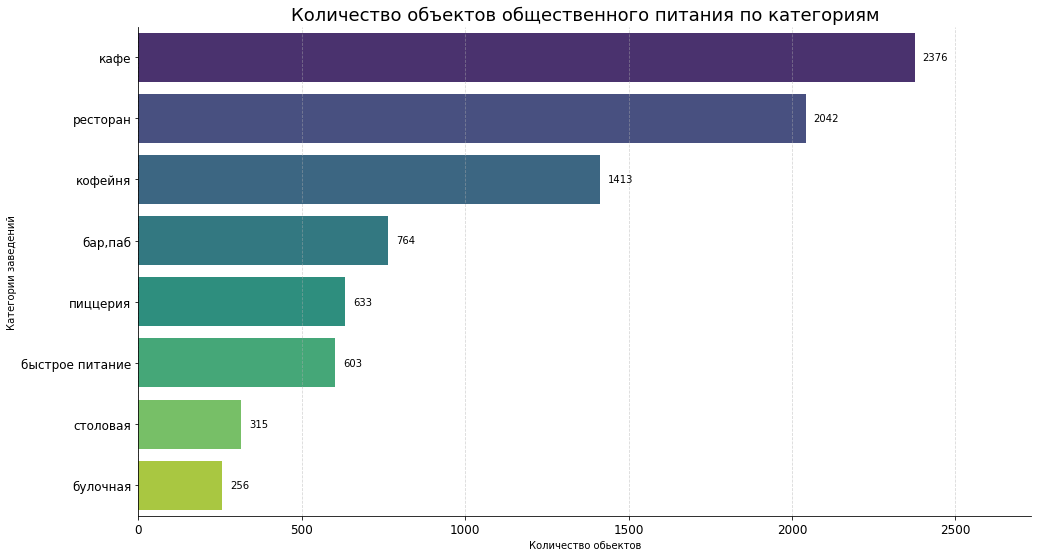

In [47]:
# Группируем данные
category_counts = (
    rest_full.groupby('category')['name']
    .count()
    .reset_index()
    .sort_values(by='name', ascending=False)
)
# Задаем физические размеры полотна графика
plt.figure(figsize=(16, 9))

# Отрисовываем горизонтальные столбцы
ax = sns.barplot(
    x='name',
    y='category',
    data=category_counts,
    palette='viridis',
    order=category_counts['category']
)

# Добавим подписи
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + category_counts['name'].max() * 0.01,  # небольшой отступ
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center'
    )

plt.title('Количество объектов общественного питания по категориям', fontsize=18)
plt.xlabel('Количество обьектов')
plt.ylabel('Категории заведений')

plt.yticks(fontsize=12)
plt.xticks(fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, category_counts['name'].max() * 1.15)

sns.despine()

plt.show()

In [48]:
# Рассчитаем доли в процентах
category_table = category_counts.copy()
category_table.columns = ['Категория', 'Количество объектов']
total_rest = category_table['Количество объектов'].sum()
category_table['Доля, %'] = (category_table['Количество объектов'] / total_rest * 100).round(1)

display(category_table.reset_index(drop=True))

,Категория,Количество объектов,"Доля, %"
0,кафе,2376,28.3
1,ресторан,2042,24.3
2,кофейня,1413,16.8
3,"бар,паб",764,9.1
4,пиццерия,633,7.5
5,быстрое питание,603,7.2
6,столовая,315,3.7
7,булочная,256,3.0


###### На основе полученной таблицы и графика можно выделить следующие ключевые моменты:

- **Лидеры рынка**: 

Самые массовые форматы — `кафе` (**2376 объектов, 28.3% рынка**) и `рестораны` (**2042 объекта, 24.3%**). Суммарно они составляют более половины всех заведений в выборке. Это подтверждает, что классические форматы с полноценным обслуживанием являются основой общепита города.

- **Рост кофейной культуры**:

`Кофейни` (**1413 объектов**) занимают уверенное третье место с долей **16.8%**. Это значительный показатель, указывающий на высокую популярность формата "кофе с собой" и небольших заведений для отдыха.

- **Средний сегмент**: 

Категории `бар,паб` (**764**), `пиццерия` (**633**) и `быстрое питание` (**603**) имеют доли от **7.2% до 9.1%**. Относительно невысокая доля фастфуда в общем количестве может объясняться тем, что такие точки часто консолидированы в крупные сети в торговых центрах.

- **Нишевые форматы**: 

Меньше всего представлены столовые (**3.7%**) и булочные (**3%**). Это специфические форматы с ограниченным временем работы или узким ассортиментом, ориентированные на локальный спрос.

**Итоговое резюме**: 

Рынок характеризуется высокой концентрацией в сегментах `кафе и ресторанов`. Для нового проекта (кофейни с роботами, например) наиболее близким конкурентным окружением станут кофейни, занимающие почти пятую часть рынка.

#### *Отдельно посмотрим ценовой сегмент кофейн, учитывая, что заполнено всего 535 строк в столбце `middle_coffee_cup`*

In [49]:
# Выводим основные статистики
stats = rest_full['middle_coffee_cup'].describe()
display("Основные показатели цен:")
display(stats)

# Cчитаем размах
price_range = rest_full['middle_coffee_cup'].max() - rest_full['middle_coffee_cup'].min()
print(f"Общий разброс цен (Max - Min): {price_range} руб.")

# Считаем медиану 
median_price = rest_full['middle_coffee_cup'].median()
print(f"Медианная цена: {median_price} руб.")

'Основные показатели цен:'

count     535.000000
mean      174.721495
std        88.951103
min        60.000000
25%       124.500000
50%       169.000000
75%       225.000000
max      1568.000000
Name: middle_coffee_cup, dtype: float64

Общий разброс цен (Max - Min): 1508.0 руб.
Медианная цена: 169.0 руб.


Отфильтруем значения, оставив только те, что меньше 600 рублей:

In [50]:
clean_prices = rest_full[rest_full['middle_coffee_cup'] < 600]['middle_coffee_cup']

display(clean_prices.describe().round(2))

# Считаем размах для очищенных данных
clean_range = round(clean_prices.max() - clean_prices.min(), 2)
print(f"Реальный разброс цен (без аномалий): {clean_range} руб.")

count    534.00
mean     172.11
std       65.41
min       60.00
25%      124.25
50%      168.00
75%      225.00
max      375.00
Name: middle_coffee_cup, dtype: float64

Реальный разброс цен (без аномалий): 315.0 руб.


*Мы изучили **535 кофейн** и очистили данные от случайных ошибок (убрали аномальный скачок в 1568 ₽, который был ошибкой в базе).* 

**Реальная цена на рынке**: Большинство заведений продают среднюю чашку в диапазоне от 125 до 225 рублей.

Идеальное попадание: Самая «справедливая» цена, на которую ориентируется массовый клиент — 168 рублей.

Важный нюанс: Средний показатель в 172 рублей немного завышен из-за дорогих премиальных точек, поэтому для быстрого старта лучше держаться ближе к медиане (169 ₽).

<a id='chapter3.2'></a>
### 3.2. Распределение объектов общественного питания по районам

Изучим территориальное расположение заведений в масштабах города и специфику концентрации различных форматов общепита в ЦАО.

#### Количество заведений по районам Москвы
Построим столбчатую диаграмму, чтобы сравнить количество заведений по районам Москвы:

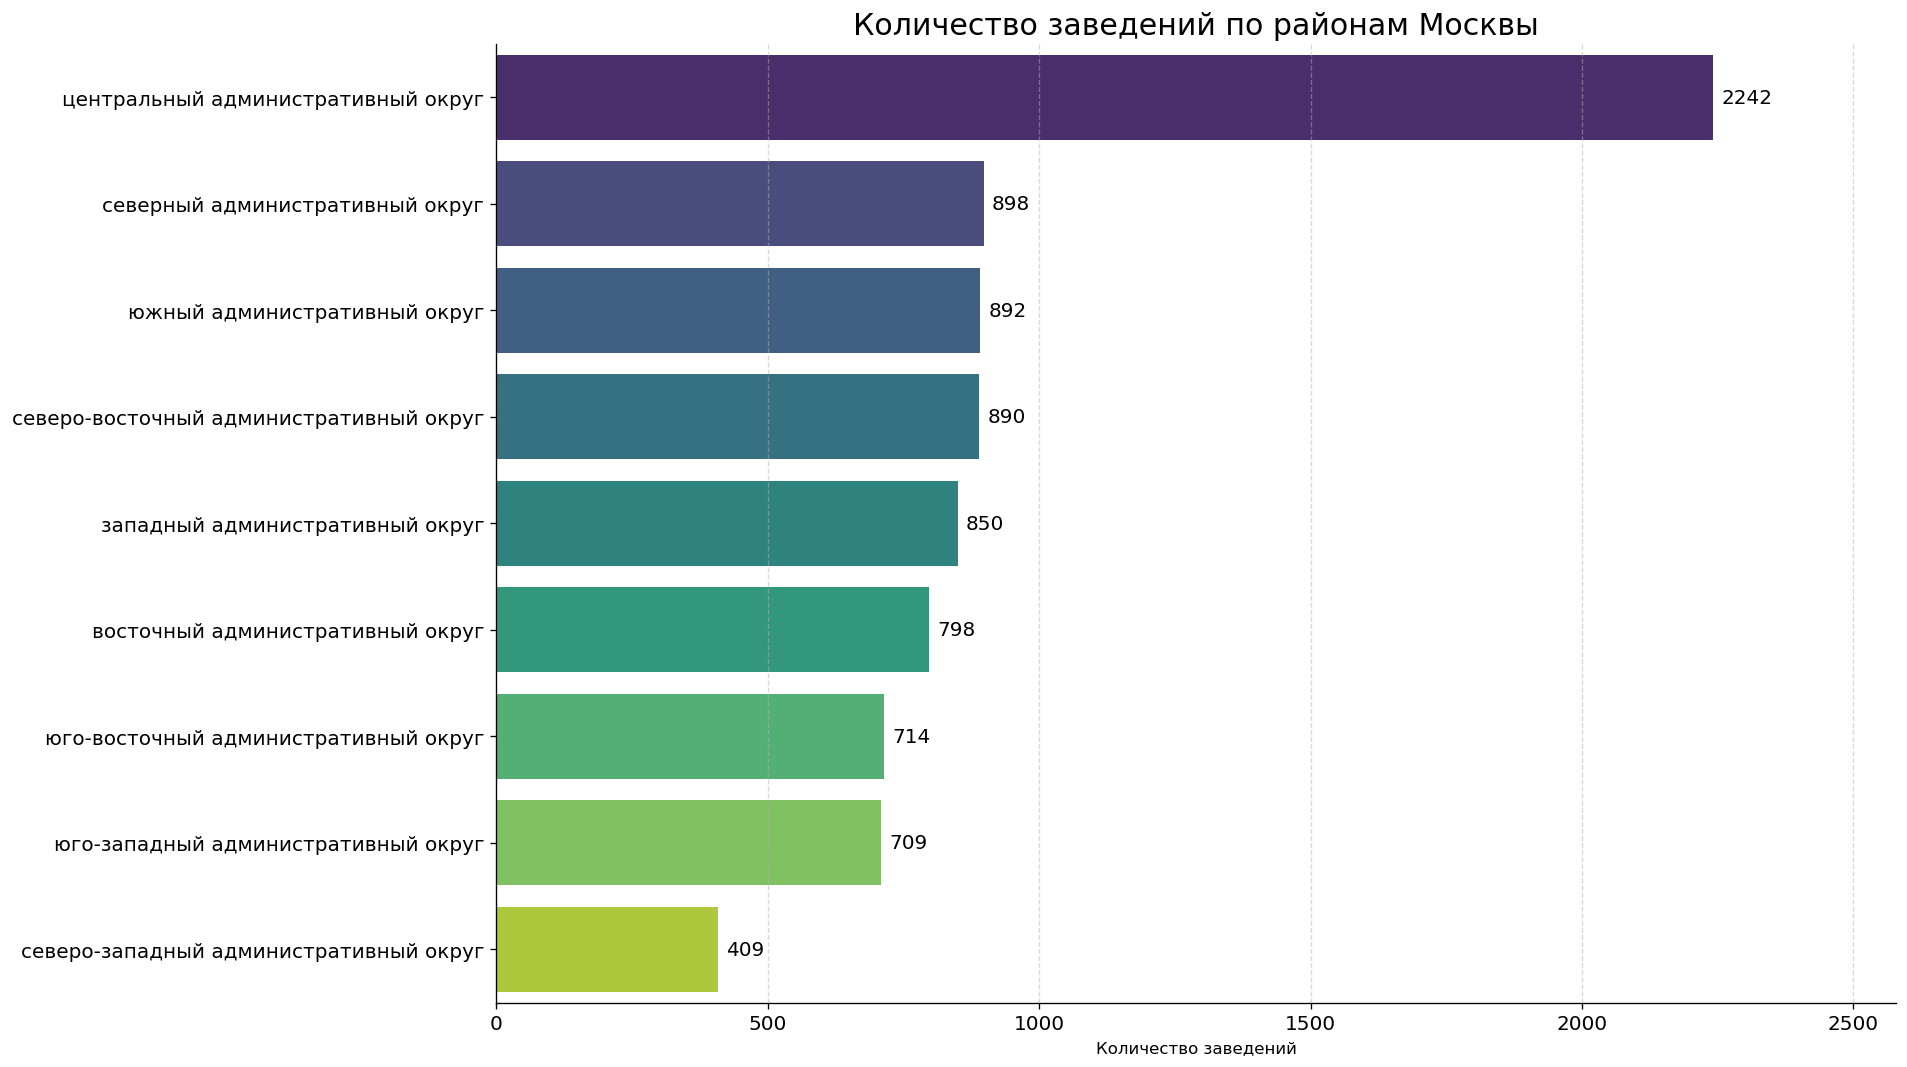

In [51]:
# Группируем количество заведений по районам
district_counts = (
    rest_full.groupby('district')['name']
    .count()
    .reset_index()
    .sort_values(by='name', ascending=False)
)

# Визуализация
plt.figure(figsize=(16, 9), dpi=120) 
ax = sns.barplot(
    x='name',
    y='district',
    data=district_counts,
    palette='viridis',
    order=district_counts['district']
)

# Подписиваем столбцы
for p in ax.patches:
    width = p.get_width()
    # Проверка на NaN и отрисовка только существующих значений
    if width == width and width > 0:
        ax.annotate(f'{int(width)}', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points',
                    fontsize=12,
                    fontweight='normal')

plt.title('Количество заведений по районам Москвы', fontsize=18) 
plt.ylabel('')
plt.xlabel('Количество заведений')

# Настройка шрифтов осей для крупного графика
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, district_counts['name'].max() * 1.15)

# Удаляем лишние границы графика
sns.despine() 
plt.tight_layout()
plt.show()


Изучим относительные показатели долей количества заведений в разрезе районов на основе имеющихся данных.

Перед тем как формировать таблицы долей по районам и по категориям, создадим универсальную функцию.

Она позволит избежать дублирования кода, автоматически рассчитывать процентную долю категории в общей структуре.

In [52]:
def create_share_table(df, name_col, count_col):
    """
    Функция принимает датафрейм с агрегированными данными
    и возвращает таблицу с долями в процентах.
    
    df — исходная таблица
    name_col — название столбца с категорией (например, 'Район')
    count_col — название столбца с количеством
    """
    
    table = df.copy()
    
    # Переименование столбцов
    table.columns = [name_col, count_col]
    
    # Общая сумма
    total = table[count_col].sum()
    
    # Расчёт доли
    table['Доля, %'] = (table[count_col] / total * 100).round(1)
    
    # Сортировка по убыванию (чтобы выглядело аккуратнее)
    table = table.sort_values(by=count_col, ascending=False)
    
    return table.reset_index(drop=True)

Создадим таблицу долей по районам:

In [53]:
district_table = create_share_table(
    district_counts,
    name_col='Район',
    count_col='Количество объектов'
)

display(district_table)

,Район,Количество объектов,"Доля, %"
0,центральный административный округ,2242,26.7
1,северный административный округ,898,10.7
2,южный административный округ,892,10.6
3,северо-восточный административный округ,890,10.6
4,западный административный округ,850,10.1
5,восточный административный округ,798,9.5
6,юго-восточный административный округ,714,8.5
7,юго-западный административный округ,709,8.4
8,северо-западный административный округ,409,4.9


####  Где в Москве больше всего заведений?

- **Абсолютный лидер — ЦАО**: Здесь сосредоточено **2242 или 26.7%** всех объектов (каждое четвертое заведение города). Конкуренция в центре в 2.5 раза выше, чем в любом другом округе.

- **«Плотный пояс» (САО, ЮАО, СВАО, ЗАО**): Эти четыре округа идут очень ровно — в каждом примерно по **10%** рынка (около 900 объектов). Это стабильные районы с хорошим насыщением.

- **Средние показатели (ВАО, ЮВАО, ЮЗАО**): Имеют долю около **8.5–9.5%** (от 800 до 900 объектов). Здесь рынок еще имеет потенциал для роста.

- **Самый свободный район — СЗАО**: Всего **4.9%**, а именно 409 заведений. Это округ с самой низкой плотностью объектов общепита в нашей выборке.

#### Распределение категорий заведений в ЦАО
Построим столбчатую диаграмму, чтобы сравнить количество заведений в Центральном административном округе:

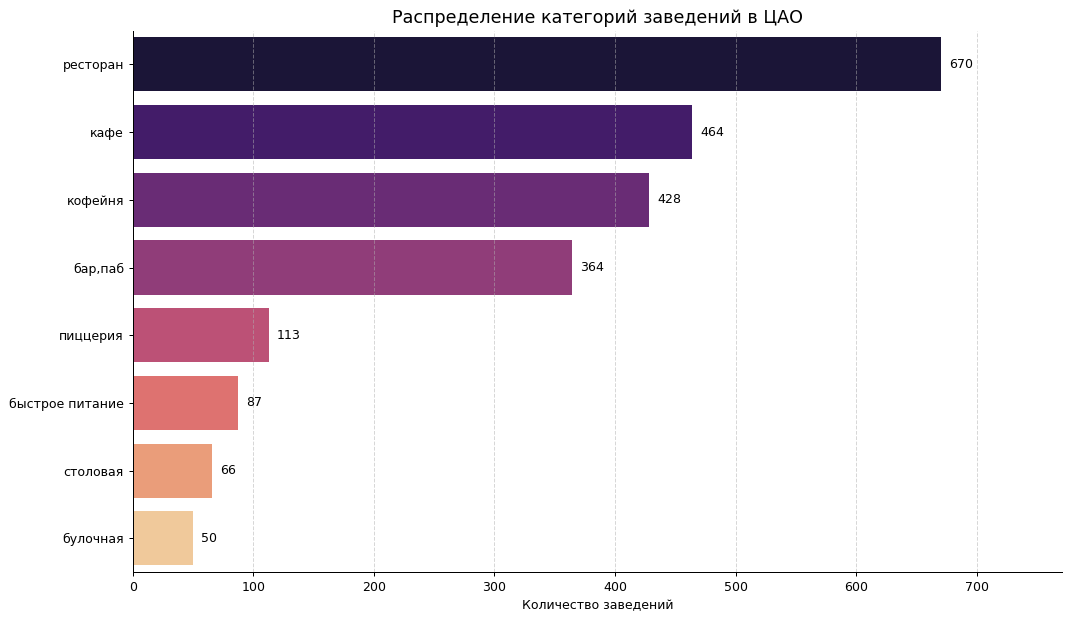

In [54]:
# Фильтруем Центральный административный округ
cao_df = rest_full[rest_full['district'] == 'центральный административный округ']

# Группируем по категориям
cao_category_counts = (
    cao_df.groupby('category')['name']
    .count()
    .reset_index()
    .sort_values(by='name', ascending=False)
)

# Устанавливаем dpi для высокой четкости и размер полотна
plt.figure(figsize=(12, 7), dpi=90)

ax = sns.barplot(
    x='name',
    y='category',
    data=cao_category_counts,
    palette='magma',
    order=cao_category_counts['category']
)

# Добавляем подписи
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + cao_category_counts['name'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center'
    )

plt.title('Распределение категорий заведений в ЦАО', fontsize=14)
plt.xlabel('Количество заведений')
plt.ylabel('')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, cao_category_counts['name'].max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

Создаем таблицу долей для ЦАО:

In [55]:
cao_category_table = create_share_table(
    cao_category_counts,
    name_col='Категория',
    count_col='Количество объектов'
)

display(cao_category_table)

,Категория,Количество объектов,"Доля, %"
0,ресторан,670,29.9
1,кафе,464,20.7
2,кофейня,428,19.1
3,"бар,паб",364,16.2
4,пиццерия,113,5.0
5,быстрое питание,87,3.9
6,столовая,66,2.9
7,булочная,50,2.2


- В **ЦАО** наибольшую долю занимают рестораны (**29,9%, 670 объектов**) — почти треть всех объектов. Это подтверждает статус центра как деловой и туристической зоны с высокой концентрацией заведений полного формата обслуживания.

- Вторую и третью позиции занимают **кафе** (**20,7%, 464 объекта**) и **кофейни** (**19,1%, 428 объектов**), что говорит о высоком спросе на повседневные форматы питания и кофе-поинты. 

- Существенную долю также составляют бары и пабы (**16,2%, 364 объекта**), что отражает активную вечернюю и развлекательную инфраструктуру центра.

- Менее представлены **пиццерии** (**5%, 113 объектов**), **быстрое питание** (**3,9%, 87 объекта**), **столовые** (**2,9, 66 объекта%**) и **булочные**, что может свидетельствовать о более высокой конкуренции в сегменте полноформатных заведений и меньшей концентрации бюджетных форматов в ЦАО.

<a id='chapter3.3'></a>
### 3.3. Соотношение сетевых и несетевых заведений

Посмотрим соотношение сетевых и несетевых заведений в целом и подсчитаем количество долей

In [56]:
# Посчитаем количество сетевых и несетевых заведений
chain_total = (
    rest_full['chain']
    .value_counts()
    .rename_axis('chain')
    .reset_index(name='Количество_заведений')
)

# Долей
chain_total['Доля, %'] = (
    chain_total['Количество_заведений'] / chain_total['Количество_заведений'].sum() * 100
).round(1)

display(chain_total)

,chain,Количество_заведений,"Доля, %"
0,0,5199,61.9
1,1,3203,38.1


На рынке преобладают **несетевые** заведения (**61,9%**), тогда как доля **сетевых** составляет **38,1%**. 

Для наглядности визуализируем соотношение сетевых и несетевых заведений:

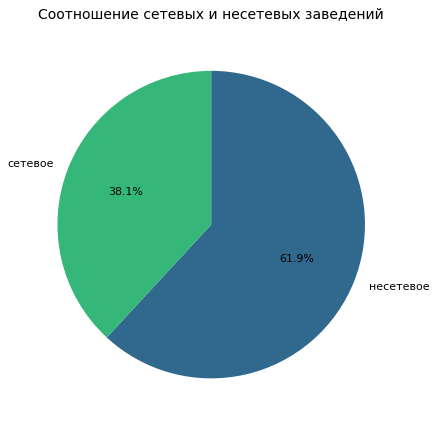

In [57]:
# Данные
labels = ['несетевое', 'сетевое']
sizes = chain_total['Количество_заведений']

# Получаем цвета из палитры viridis
colors = sns.color_palette('viridis', n_colors=len(sizes))

plt.figure(figsize=(8, 6))

# Круговая диаграмма
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 11}
)

plt.title('Соотношение сетевых и несетевых заведений', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

В выборке преобладают **несетевые заведения — 61,9% (5199 объектов)**.
Доля **сетевых** заведений составляет **38,1% (3203 объекта)**.

Таким образом, рынок общественного питания Москвы преимущественно представлен независимыми игроками, однако доля сетевых заведений также значительна — почти 2 из 5 объектов работают в формате сети.

Изучим распределение по категориям - количество сетевых и несетевых внутри каждой категории:

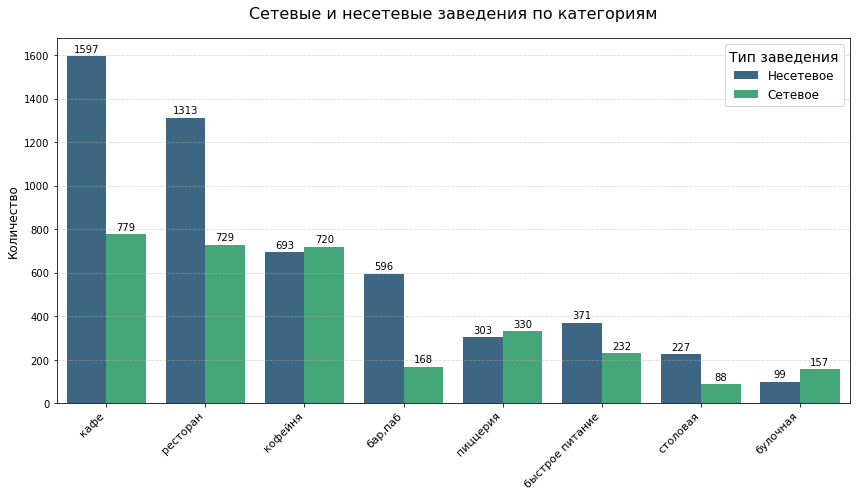

In [58]:
# Группируем количество сетевых и несетевых заведений по категориям
category_chain = (
    rest_full.groupby(['category', 'chain'])['name']
    .count()
    .reset_index()
    .rename(columns={'name': 'Количество'})
)

# Группируем количество заведений по категориям для сортировки
category_order = (
    category_chain.groupby('category')['Количество']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Визуализация
plt.figure(figsize=(12, 7)) 

ax = sns.barplot(
    data=category_chain,
    x='category',
    y='Количество',
    hue='chain',
    palette='viridis',
    order=category_order 
)

# Добавляем цифры над столбцами 
for p in ax.patches:
    height = p.get_height()
    # Проверка на NaN и исключение нулевых/пустых значений
    if height == height and height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 2), 
                    textcoords='offset points',
                    fontsize=10)

# Настраиваем крупную легенду с новыми названиями
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    ['Несетевое', 'Сетевое'], 
    title='Тип заведения', 
    fontsize=12,         
    title_fontsize=14,   
    loc='upper right'    
)

# Настройка осей и заголовка
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Сетевые и несетевые заведения по категориям', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('Количество', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


Глядя на график и полученные цифры, можно сформулировать следующий лаконичный итог:

**Сетевая модель** наиболее успешно закрепилась в сегментах с высокой степенью стандартизации: **булочные (61.3%), пиццерии (52.1%) и кофейни (51.0%)** уже более чем наполовину состоят из сетевых точек. 

В то же время классические форматы с акцентом на **индивидуальность** и атмосферу — **бары (22.0%) и столовые (27.9%)** — остаются территорией частного локального бизнеса.

Отдельно рассмотрим долю сетевых заведений в каждой категории:

In [59]:
# Вычисляем долю сетевых заведений по категориям
category_share = (
    rest_full.groupby('category')['chain']
    .mean()
    .reset_index()
)

# Рассчитываем процентную долю
category_share['Доля сетевых, %'] = (category_share['chain'] * 100).round(1)

# Сортируем категории по убыванию
category_share = category_share.sort_values(by='Доля сетевых, %', ascending=False)

display(category_share[['category', 'Доля сетевых, %']])

,category,"Доля сетевых, %"
1,булочная,61.3
5,пиццерия,52.1
4,кофейня,51.0
2,быстрое питание,38.5
6,ресторан,35.7
3,кафе,32.8
7,столовая,27.9
0,"бар,паб",22.0


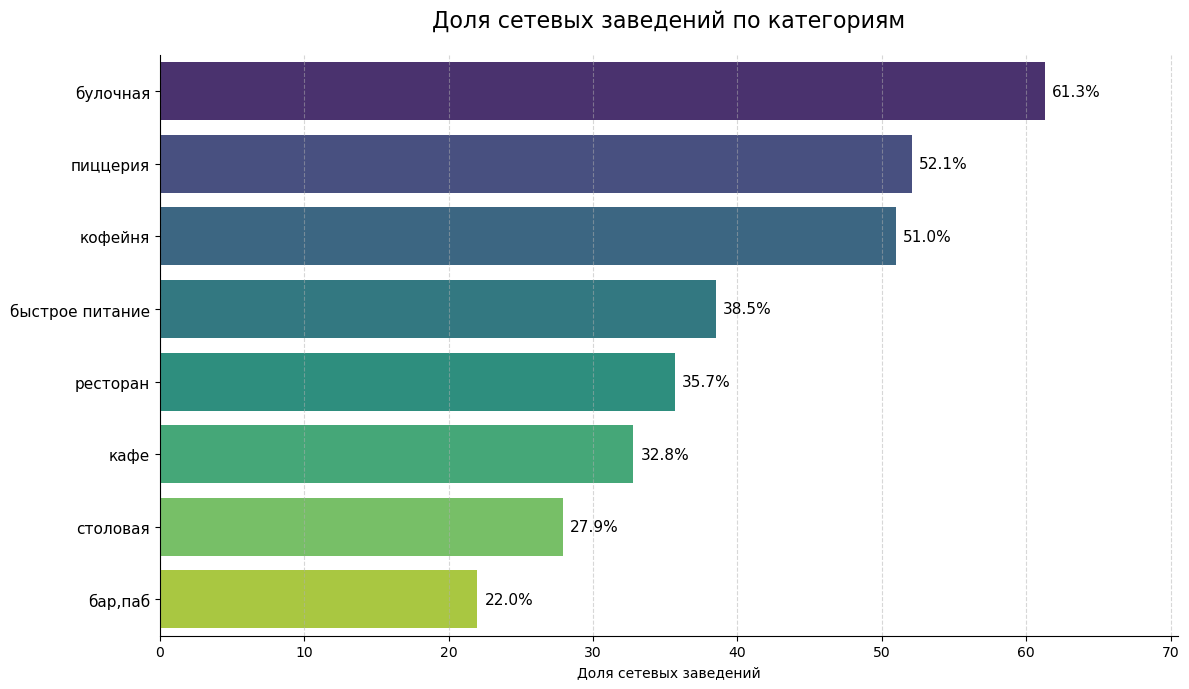

In [60]:
# Устанавливаем размер полотна и dpi для большей четкости
plt.figure(figsize=(12, 7), dpi=100)

# Строим горизонтальный график
ax = sns.barplot(
    data=category_share,
    x='Доля сетевых, %',
    y='category',
    palette='viridis'
)

# Добавляем подписи данных 
for p in ax.patches:
    width = p.get_width()
    # Проверка на NaN
    if width == width and width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points',
                    fontsize=11)

# Оформление заголовка и осей
plt.title('Доля сетевых заведений по категориям', fontsize=16, pad=20)
plt.xlabel('Доля сетевых заведений')
plt.ylabel('')

# Настройка шрифтов осей
plt.xticks(fontsize=10)
plt.yticks(fontsize=11)

# Настраиваем сетку по оси X
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Запас по оси X, чтобы цифры не вылезали за край
plt.xlim(0, category_share['Доля сетевых, %'].max() * 1.15)

# Удаляем лишние границы
sns.despine()

plt.tight_layout()
plt.show()


1. Массовый сегмент (**Кафе и рестораны**)

Это самые крупные ниши города. Здесь **доминирует частный бизнес**: 1597 кафе и 1313 ресторанов против 779 и 729 сетевых объектов соответственно. Доля сетей составляет около 33–36%. Это подтверждает, что в полноценном общепите люди всё еще ценят уникальность и авторский подход выше стандартов.

2. Ниши под контролем сетей (**Кофейни, пиццерии, булочные**)

Это единственные категории, где **сетевых точек физически больше**, чем частных.
  - **Булочные**: самая высокая концентрация сетей на рынке — 61.3% (157 сетевых против 99 частных). При этом по общему количеству объектов это самый маленький сегмент рынка.
  - **Пиццерии**: доля сетей 52.1% (330 сетевых против 303 частных).
  - **Кофейни**: доля сетей 51.0% (720 сетевых против 693 частных).
 
Вывод: Заходить сюда сложнее всего — придется конкурировать с отлаженными процессами и бюджетами крупных брендов.

3. Пространство для концептов (**Бары и пабы**)

**Здесь самый яркий контраст**. Несетевых **баров почти в 3.5 раза больше (596 против 168)**, а доля сетевиков — минимальные 22.0%. Это лучшая ниша для запуска крафтового или тематического проекта, так как сетевые гиганты здесь практически не представлены.

4. **Фастфуд и столовые**

Вопреки стереотипам, в быстром питании **несетевых точек больше: 371 против 232 сетевых (доля сетей — 38.5%)**. В столовых сетевой сегмент развит еще слабее — всего 27.9% (88 сетевых на 227 частных). Это говорит о живучести локальных форматов «у дома» и «у работы», которые успешно конкурируют с брендами за счет доступности.

<a id='chapter3.4'></a>
### 3.4. Распределение посадочных мест по типам заведений
Изучим вместимость объектов и характерные нормы посадки с учётом специфики типов общепита, структуры данных и возможных аномальных значениях. 

#### Общее распределение посадочных мест
Для наглядности визуализируем общее распределение количества посадочных мест с помощью гистограммы:

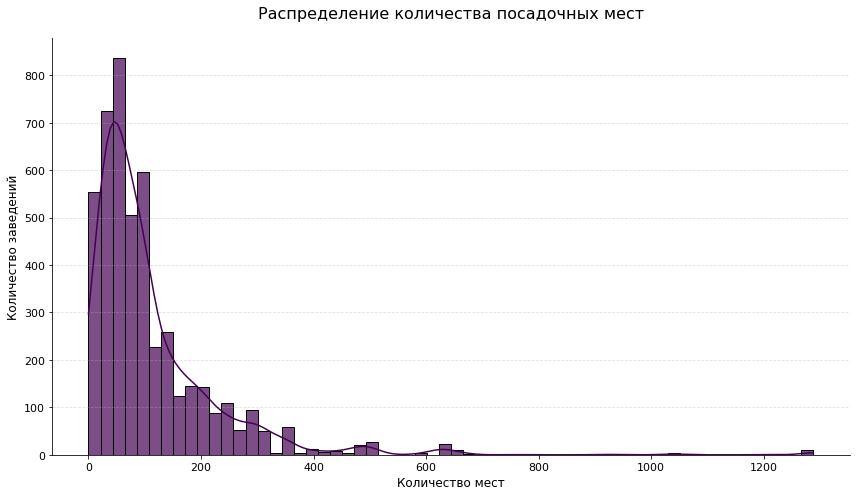

In [61]:
# Устанавливаем размер полотна 
plt.figure(figsize=(12, 7))

# Преобразуем тип данных и убираем пустоты
plot_data = pd.to_numeric(rest_full['seats'], errors='coerce').astype(float).dropna()

# Строим гистограмму
sns.histplot(
    plot_data,
    bins=60,            
    kde=True,          
    color='#440154',     
    edgecolor='black',   
    alpha=0.7            
)

# Оформление заголовка и осей
plt.title('Распределение количества посадочных мест', fontsize=16, pad=20)
plt.xlabel('Количество мест', fontsize=12)
plt.ylabel('Количество заведений', fontsize=12)

# Настройка шрифтов делений осей
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Сетка
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()


На гистограмме распределения количества посадочных мест видно, что данные имеют выраженную правостороннюю асимметрию: основная часть заведений сосредоточена в диапазоне **до 100 мест**, а далее наблюдается постепенное снижение частоты. Однако **после** отметки **200–250 мест** начинается длинный «хвост», где встречаются **отдельные очень крупные объекты**.

Чтобы точнее определить границы типичных значений и наглядно увидеть масштаб этих аномалий, дополним анализ диаграммой размаха:

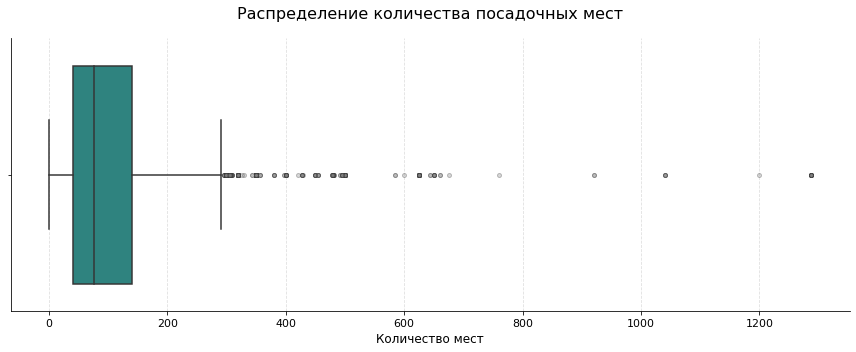

In [62]:
# Устанавливаем размер полотна
plt.figure(figsize=(12, 5)) 

# Строим горизонтальный boxplot 
ax = sns.boxplot(
    x=rest_full['seats'],
    color='#21918c',      
    flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 4, 'alpha': 0.3} 
)

# Оформление заголовка и осей с увеличенным шрифтом
plt.title('Распределение количества посадочных мест', fontsize=16, pad=20)
plt.xlabel('Количество мест', fontsize=12)

# Настройка шрифтов делений оси
plt.xticks(fontsize=11)

# Настраиваем сетку 
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Удаляем лишние границы графика 
sns.despine()

plt.tight_layout()
plt.show()


Диаграмма размаха подтверждает выводы, сделанные на этапе гистограммы, и вносит дополнительную точность:

**Типичная вместимость**: Медиана находится на уровне **80–100 мест**, а основная масса заведений сосредоточена в диапазоне от **40 до 150 мест**.

**Граница нормальных значений**: Верхний «ус» заканчивается в районе **280–300 мест**. Всё, что находится правее этой отметки, статистически считается выбросами.

**Аномальные объекты**: Мы видим значительное количество экстремальных значений — отдельные гиганты на 600, 1000 и даже 1200+ мест. Эти объекты сильно смещают среднее значение вверх и требуют отдельного внимания (возможно, это крупные банкетные залы или стадионы).

**Изучим заведения с «аномальным» количеством мест** — те, что сильно выделяются на фоне остальных.

In [63]:
# Создаём функцию для подсчёта количества выбросов
def count_outliers(group):
    Q1 = group['seats'].quantile(0.25)
    Q3 = group['seats'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    count = (group['seats'] > upper_bound).sum()
    share = (count / len(group) * 100).round(1) # Доля в %
    
    return pd.Series({
        'Количество выбросов': count,
        'Доля выбросов, %': share
    })

outliers_summary = (
    rest_full
    .dropna(subset=['seats'])
    .groupby('category')
    .apply(count_outliers)
    .sort_values('Количество выбросов', ascending=False)
)

display(outliers_summary)

,Количество выбросов,"Доля выбросов, %"
category,,
кафе,98.0,8.4
ресторан,70.0,5.6
кофейня,40.0,5.3
"бар,паб",35.0,7.6
пиццерия,27.0,6.5
быстрое питание,14.0,4.0
столовая,13.0,8.2
булочная,11.0,7.4


Подсчёт объектов, выходящих за границы типичных значений, показал интересную структуру рынка:

Категория **«Кафе»** имеет самое большое количество выбросов (**98 объектов**), что составляет **8.4%** от всех заведений этого типа. Это подтверждает универсальность формата: под вывеской «кафе» могут работать как крошечные точки, так и огромные банкетные залы.

В категориях **«Столовая»** (**8.2%**) и **«Бар, паб»** (**7.6%**) доля выбросов также высока. Это логично: столовые часто проектируются под нужды крупных предприятий или учебных заведений, а пабы могут занимать большие площади в популярных локациях.

В категории **«Быстрое питание»** зафиксировано наименьшее количество и самая низкая доля выбросов (**4%**). Сетевой характер этого бизнеса диктует жесткие нормы вместимости, поэтому объекты здесь чаще всего предсказуемы по площади.

**Общий итог**: Наличие во всех категориях (кроме фастфуда) от 5% до 8% аномально крупных объектов говорит о том, что для точного анализа среднего заведения нам следует **ориентироваться на медиану**, а не на среднее арифметическое, которое сильно искажено этими «гигантами».
Выбросы присутствуют во всех категориях, но **носят редкий и закономерный характер**, отражая сегмент очень крупных заведений.

Рассчитаем медианную вместимость по типам объектов общественного питания:

In [64]:
# Оставляем только строки с заполненным количеством мест
seats_data = rest_full[['category', 'seats']].dropna().copy()

# Рассчитываем медианную вместимость для каждой категории
seats_by_category = (
    seats_data
    .groupby('category')['seats']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

# Переименовываем столбцы
seats_by_category.columns = ['Категория', 'Медианное число мест']

display(seats_by_category)

,Категория,Медианное число мест
0,ресторан,90.0
1,"бар,паб",84.0
2,кофейня,80.0
3,столовая,80.0
4,быстрое питание,65.0
5,кафе,60.0
6,пиццерия,56.0
7,булочная,50.0


Построим диаграмму типичного (медианного) количества посадочных мест:

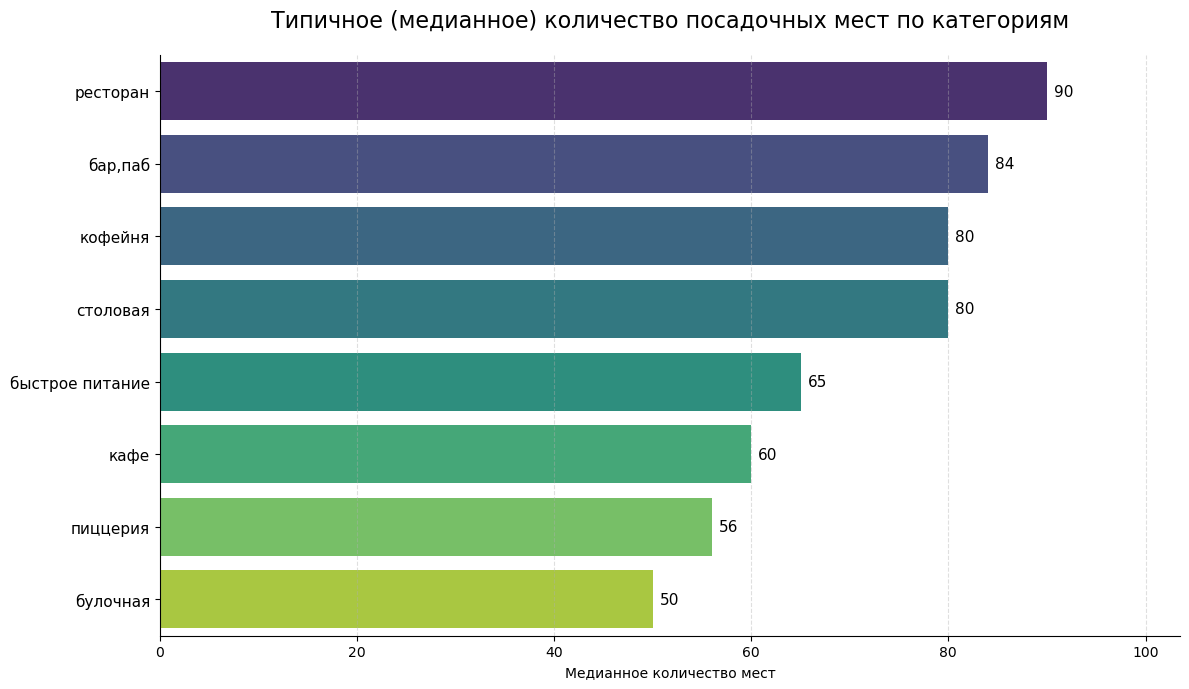

In [65]:
# Устанавливаем размер полотна и dpi для большей четкости
plt.figure(figsize=(12, 7), dpi=100)

# Строим график
ax = sns.barplot(
    data=seats_by_category,
    x='Медианное число мест',
    y='Категория',
    hue='Категория',
    palette='viridis',
    dodge=False
)

# Добавляем подписи данных 
for p in ax.patches:
    width = p.get_width()
    # Проверка на NaN и исключение пустых значений
    if width == width and width > 0:
        ax.annotate(f'{int(width)}', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points',
                    fontsize=11)

# Оформление заголовка и осей
plt.title('Типичное (медианное) количество посадочных мест по категориям', fontsize=16, pad=20)
plt.xlabel('Медианное количество мест')
plt.ylabel('')

# Настройка шрифтов делений осей
plt.xticks(fontsize=10)
plt.yticks(fontsize=11)

# Убираем лишнюю легенду
plt.legend([], frameon=False)

# Сетка и очистка границ
plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine()

# Запас по оси X, чтобы цифры не обрезались
plt.xlim(0, seats_by_category['Медианное число мест'].max() * 1.15)

plt.tight_layout()
plt.show()


**Итоговый вывод** по анализу вместимости заведений:

Рынок общественного питания Москвы в основном представлен **заведениями среднего размера** — большинство объектов рассчитаны **на 50–100 гостей**. Типичное (медианное) количество мест по категориям варьируется в диапазоне от 50 до 90.

**Самыми крупными** форматами являются **рестораны** (**90 мест**) и **бары/пабы** (**84 места**). Это логично, так как данные типы заведений ориентированы на длительное пребывание гостей и соответствующий сервис.

**Кофейни и столовые** занимают стабильную среднюю позицию с показателем в **80 мест**.

Наименее вместительными оказались **объекты быстрого питания** (**65**), кафе (**60**), **пиццерии** (**56**) и **булочные** (**50**), что отражает специфику их работы (высокая оборачиваемость столов или покупка навынос).

В ходе исследования были выявлены значительные выбросы — заведения с вместимостью свыше 240–314 мест, при этом отдельные гиганты превышают отметку в 1000 мест. 
Подобные аномалии носят редкий и закономерный характер: они отражают существование сегмента очень крупных банкетных площадок, фуд-холлов или стадионов и не искажают общую картину рынка при использовании медианных расчётов.

Таким образом, московский общепит — это **рынок крепкого «среднего класса» заведений**. У каждой категории есть свои четкие и предсказуемые стандарты по количеству столов.

<a id="my_target"></a>
### Дополнительное исследование пропусков в столбце `seats`

**Подход к заполнению пропусков**

Количество посадочных мест напрямую зависит от категории заведения и статуса сети.

Поэтому пропуски были заполнены медианой внутри групп (`category`, `chain`).

*Также были построены и изучены*:
- гистограмма распределения посадочных мест;
- диаграмма размаха;
- таблица «Типичное количество мест по категориям»;
- график «Типичное (медианное) количество посадочных мест по категориям».

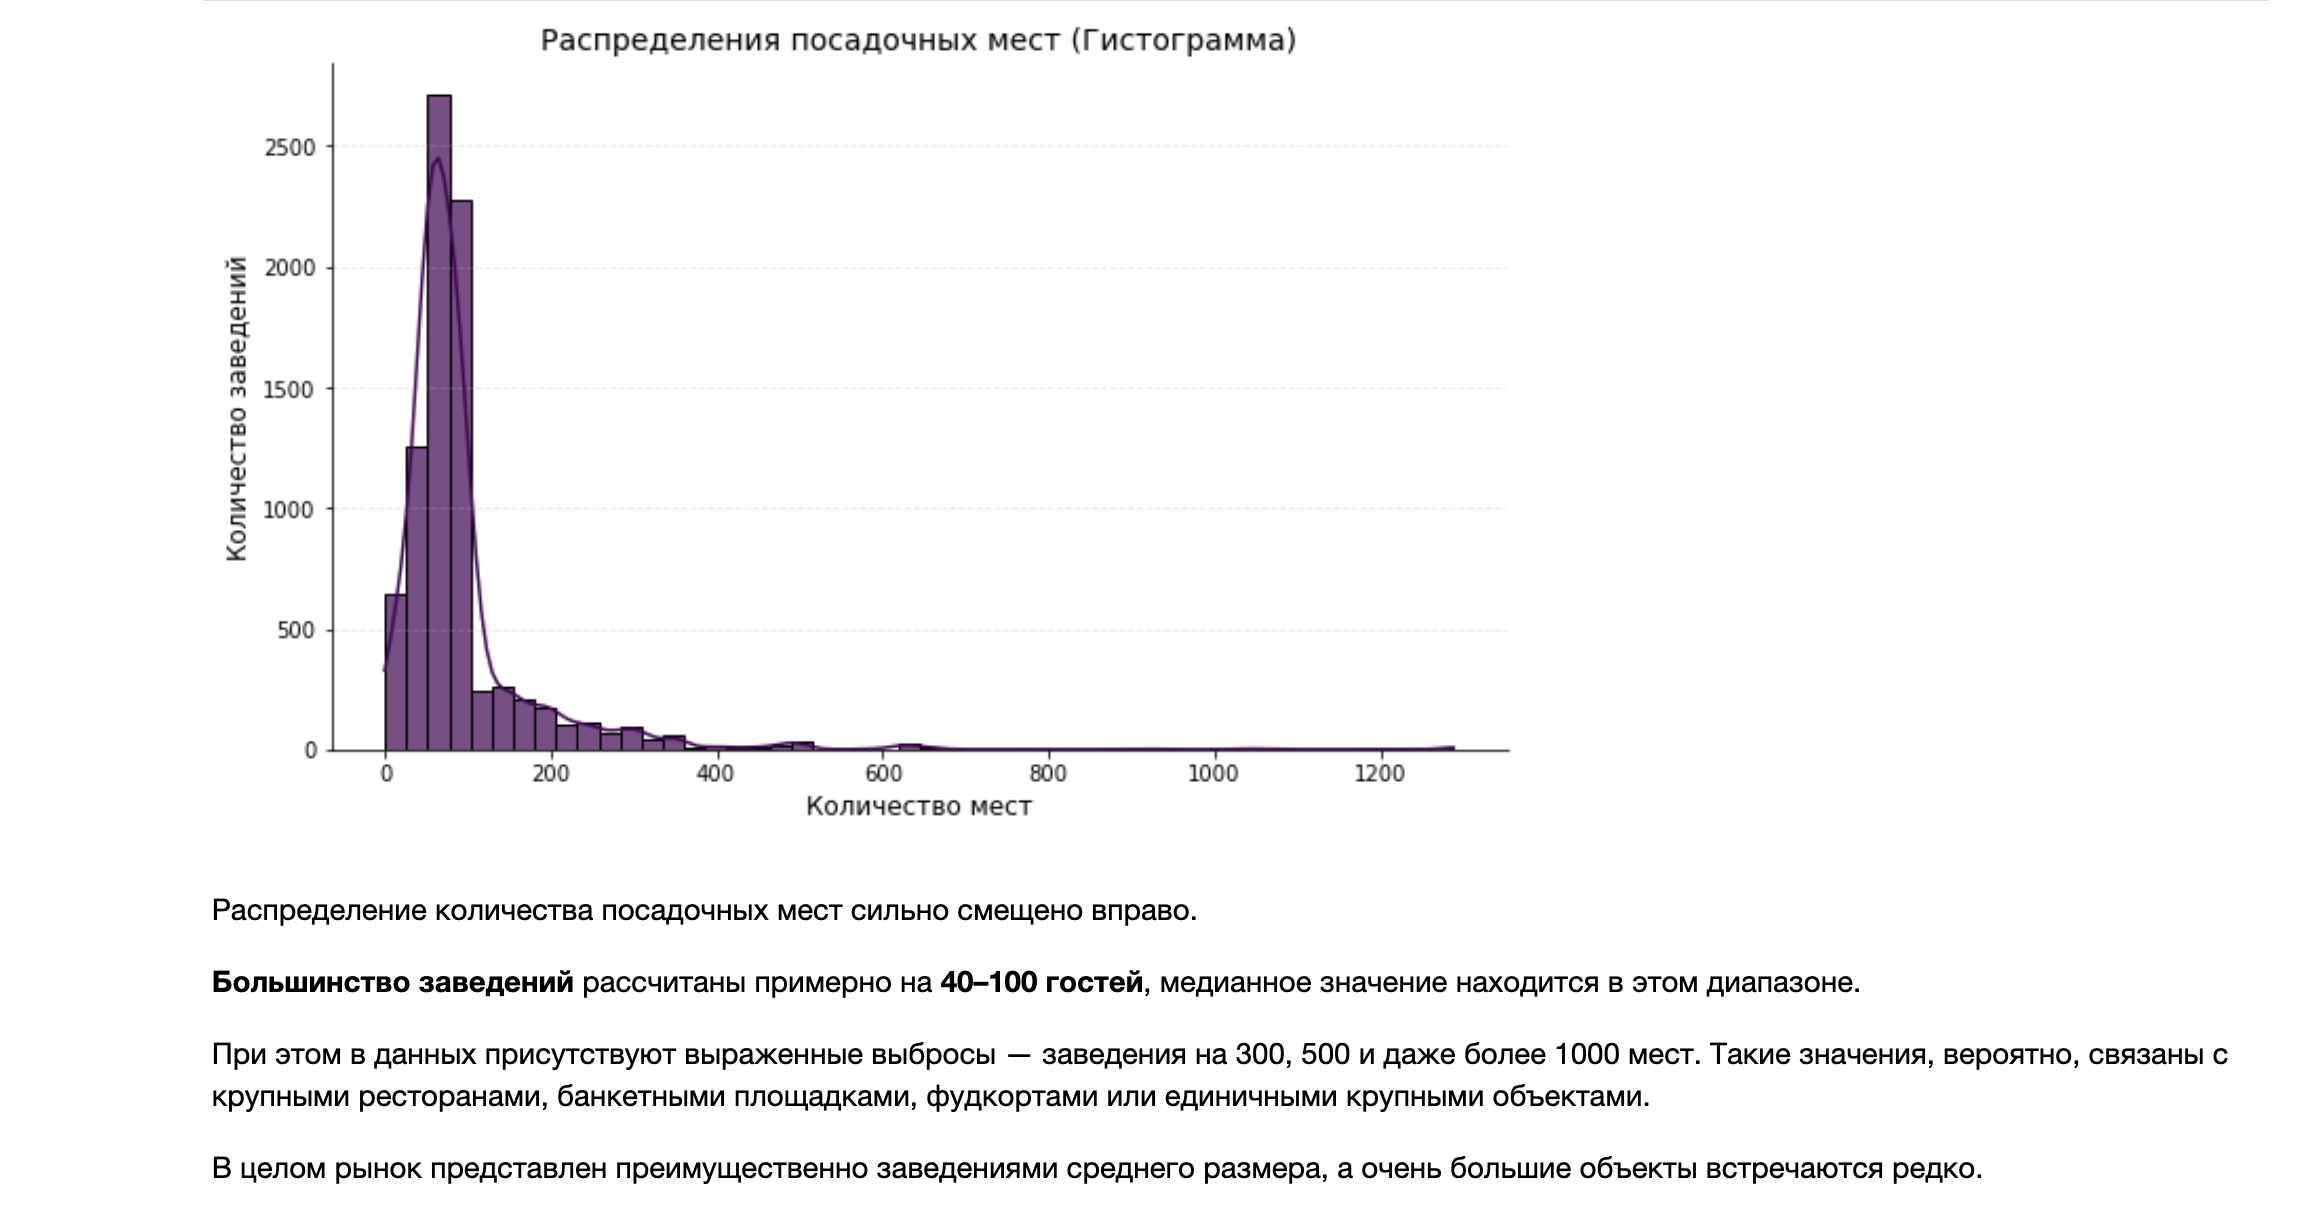

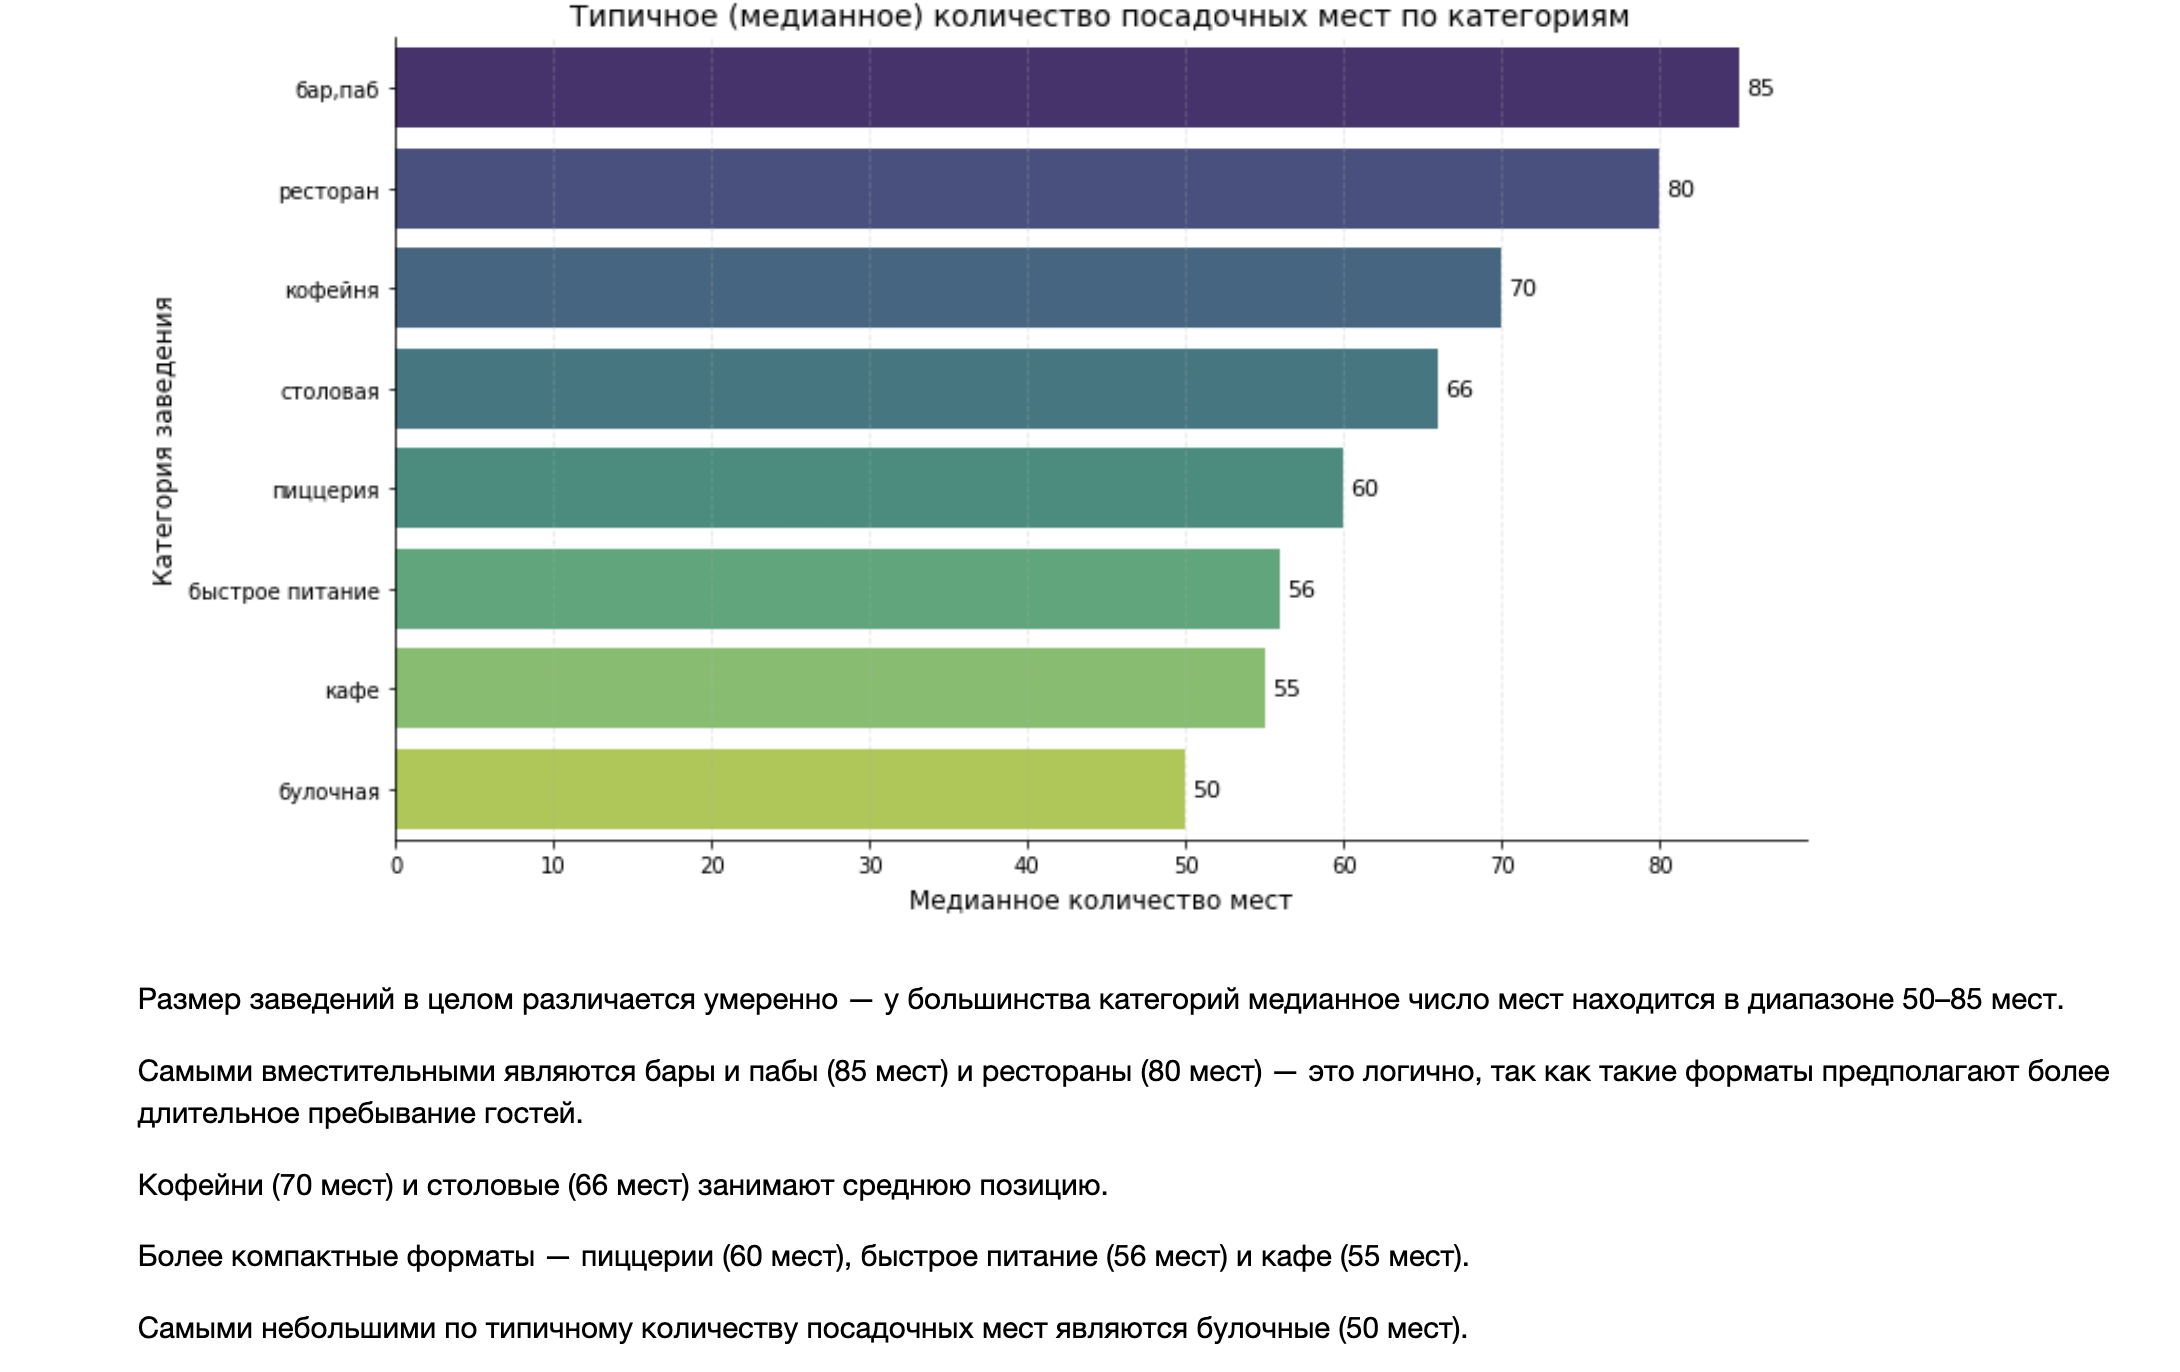


**Почему было принято решение не заполнять пропуски**:

Дополнительное тестирование с заполнением пропусков медианой по категории и признаку сети показало, что общая структура рынка сохраняется, однако распределение становится более «сглаженным».

**После замены пропусков медианой**:

- уменьшается вариативность внутри категорий,
- сокращается доля экстремальных значений относительно общего объёма данных,
- медианные показатели по категориям частично формируются за счёт добавленных значений, а не реальных наблюдений (бары "обгоняют" рестораны, что не логично).

При доле пропусков более 43%, заполнение медианой фактически означает генерацию почти половины столбца, что повышает риск искусственного искажения распределения и силы корреляций с другими признаками.

**В анализе без заполнения**:

- сохраняется естественная асимметрия распределения,
- выбросы отражают реальную структуру рынка,
- выводы основаны исключительно на фактических данных.

Поэтому для основного исследования было принято решение **не заменять пропуски**, а проводить анализ по имеющимся данным.

<a id='chapter3.5'></a>
### 3.5. Распределение рейтинга заведений по их категориям

Проанализируем пользовательские оценки и визуализируем распределение рейтингов в разрезе категорий заведений. Это позволит выяснить, существуют ли значимые различия в уровне лояльности клиентов для разных типов общепита.

Сначала необходимо убедиться, что значения рейтинга находятся в допустимых границах.

Если рейтинг задан по 5-балльной шкале, корректный диапазон:

In [66]:
# Общая статистика
rest_full['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [67]:
# Проверка на выход за границы
rest_full[(rest_full['rating'] < 0) | (rest_full['rating'] > 5)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7


Результаты подтверждают, что данные чистые и готовы к дальнейшему анализу

Посмотрим общую картину распределения рейтингов:

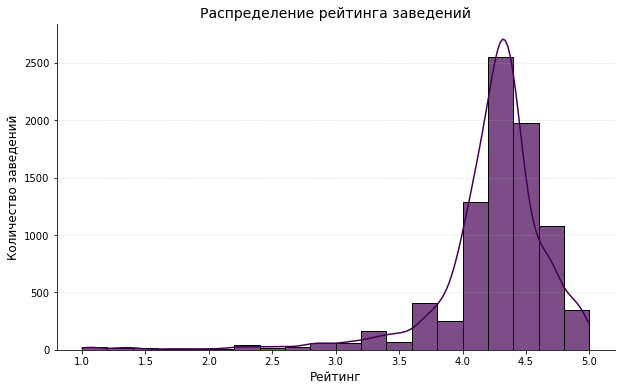

In [68]:
# Устанавливаем размер полотна 
plt.figure(figsize=(10, 6))

# Строим гистограмму распределения рейтинга
sns.histplot(
    rest_full['rating'],
    bins=20,             
    kde=True,            
    color='#440154',     
    edgecolor='black',
    alpha=0.7          
)

# Оформление заголовка и осей
plt.title('Распределение рейтинга заведений', fontsize=14)
plt.xlabel('Рейтинг', fontsize=12)
plt.ylabel('Количество заведений', fontsize=12)

# Добавляем сетку по оси Y
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Удаляем лишние границы графика 
sns.despine()

plt.show()

Распределение оценок имеет **выраженную левостороннюю асимметрию**: 
подавляющее большинство заведений Москвы имеют высокий рейтинг — основная часть оценок находится в диапазоне **4.0–4.8 балла**.

**Пик распределения**: Самое распространённое значение (мода) составляет около **4.3–4.4 балла**.

**Низкие баллы** встречаются крайне **редко** — заведений с рейтингом ниже 3.0 практически нет.

Подобная картина характерна для агрегаторов отзывов, где пользователи склонны ставить либо высокие оценки, либо не ставить их вовсе. 
В целом, рынок выглядит высококонкурентным и «качественным» с точки зрения потребительского восприятия.

Изучим средние значения рейтинга по категориям заведений и построим столбчатую диаграмму для наглядности:

In [69]:
# Рассчитаем средний рейтинг по категориям
rating_by_category = (
    rest_full.groupby('category')['rating']
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)


display(rating_by_category)

,category,rating
0,"бар,паб",4.39
1,пиццерия,4.30
2,ресторан,4.29
3,кофейня,4.28
4,булочная,4.27
5,столовая,4.21
6,кафе,4.12
7,быстрое питание,4.05


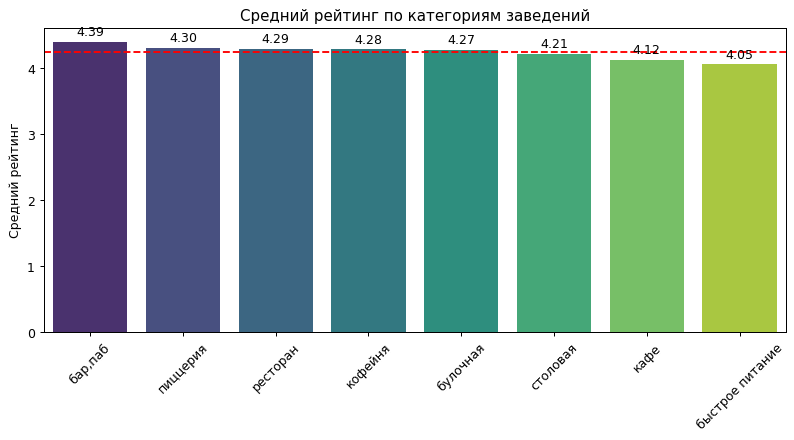

In [70]:
# Создаем фигуру и устанавливаем dpi для большей четкости
plt.figure(figsize=(9,5), dpi=90)

# Строим вертикальную столбчатую диаграмму
ax = sns.barplot(
    data=rating_by_category,
    x='category',          
    y='rating',           
    hue='category',
    palette='viridis',
    dodge=False
)

# Добавляем подписи значений над столбцами
for p in ax.patches:
    height = p.get_height()
    # Проверка на NaN и исключение нулевых значений
    if height == height and height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 3), 
                    textcoords='offset points',
                    fontsize=10)

# Рассчитываем общий средний рейтинг
overall_mean = rating_by_category['rating'].mean()

# Добавляем горизонтальную линию среднего значения
plt.axhline(
    overall_mean,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Средний рейтинг по рынку ({overall_mean:.2f})'
)

# Оформление графика
plt.title('Средний рейтинг по категориям заведений')
plt.xlabel('')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)

# Убираем лишнюю легенду
plt.legend([], frameon=False)

plt.tight_layout()
plt.show()


<a id='correlation_section'></a>**Итоговый вывод по рейтингам заведений**:

Анализ средних оценок по категориям показал высокую плотность результатов и отсутствие явных аутсайдеров:

**Самый высокий** средний рейтинг зафиксирован у **баров и пабов** (**4.39**). Этот формат пользуется наибольшей лояльностью пользователей.

Пять категорий преодолели отметку среднего уровня (4.24): это бары/пабы, пиццерии, рестораны, кофейни и булочные. Примечательно, что **столовые** (**4.21**) по качеству восприятия обходят категорию **«кафе»** (**4.12**), что является интересной особенностью московского рынка.

Самый низкий средний балл у **быстрого питания** (**4.05**). Это ожидаемо для потокового сервиса, где скорость обслуживания часто превалирует над индивидуальным подходом.

**Разрыв** между первым и последним местом составляет всего **0.34 балла**. Такая минимальная дистанция говорит о крайне плотной конкуренции и сопоставимо высоком уровне качества во всех сегментах.

**Общий итог**: Данные столбца `rating` корректны, аномалий не выявлено. **Рынок** Москвы **характеризуется «высокой планкой»** ожиданий: для успешной конкуренции заведению необходимо иметь рейтинг не ниже **4.2–4.3 балла**.

<a id='chapter3.6'></a>
### 3.6. Взаимосвязь рейтинга с характеристиками заведения
Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений

Чтобы определить, какие факторы связаны с рейтингом заведений, используем матрицу корреляции. Проанализируем его связь с другими характеристиками: категорией заведения, административным округом, сетевым статусом, количеством мест, средним чеком и признаком круглосуточной работы.

Поскольку признаки имеют разную природу — числовую (`middle_avg_bill`, `seats`) и категориальную (`category`, `district`, `chain`, `is_24_7`) — для анализа используется библиотека `phik`. Коэффициент `phi_k` позволяет корректно измерять зависимость между переменными смешанных типов, в отличие от классической корреляции Пирсона, применимой только к числовым данным.

In [71]:
# Выбираем нужные столбцы
df_phik = rest_full[['rating',
                     'category',
                     'district',
                     'chain',
                     'seats',
                     'middle_avg_bill',
                     'is_24_7', 'price']].copy()

# Удаляем строки с пропусками только для расчёта корреляции
df_phik = df_phik.dropna()

# Приводим seats к float (чтобы убрать NAType)
df_phik['seats'] = df_phik['seats'].astype(float)

# Указываем интервальные признаки
interval_cols = ['rating', 'seats', 'middle_avg_bill']

# Рассчитываем phi_k
correlation_matrix = df_phik.phik_matrix(
    interval_cols=interval_cols
)

display('Корреляция phi_k с переменной rating')

(
    correlation_matrix.loc[
        correlation_matrix.index != 'rating',
        ['rating']
    ]
    .sort_values(by='rating', ascending=False)
)

'Корреляция phi_k с переменной rating'

,rating
price,0.277041
district,0.258038
category,0.165287
is_24_7,0.087685
seats,0.075093
middle_avg_bill,0.066791
chain,0.000000


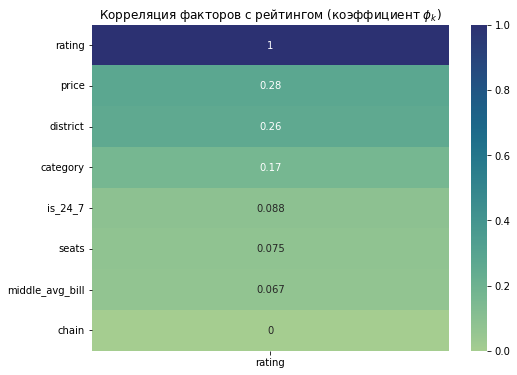

In [72]:
# Устанавливаем размер полотна
plt.figure(figsize=(8, 6))

# Визуализируем тепловую карту корреляции факторов с рейтингом
# Сортируем данные по убыванию силы связи 
sns.heatmap(
    correlation_matrix[['rating']].sort_values(by='rating', ascending=False),
    annot=True,  
    cmap='crest'    
)


plt.title('Корреляция факторов с рейтингом (коэффициент $\phi_k$)')
plt.show()

**Price (0.278)**
Самая сильная связь среди рассмотренных факторов.
Зависимость остаётся слабой (< 0.3), но наиболее выраженной в модели.
Это говорит о том, что ценовой сегмент влияет на рейтинг: заведения более высокого ценового уровня в среднем получают немного более высокие оценки.

**District (0.260)**
Связь также слабая, но заметная.
Расположение оказывает влияние на рейтинг — вероятно, в более престижных или центральных районах уровень сервиса и ожидания гостей выше.

**Category (0.165)**
Слабая зависимость.
Тип заведения влияет на восприятие качества, но значительно меньше, чем ценовой сегмент или район.

**Is_24_7 (0.088)**
Очень слабая связь.
Факт круглосуточной работы практически не влияет на рейтинг.

**Seats (0.077)**
Связь минимальная.
Размер заведения и количество посадочных мест почти не связаны с оценкой гостей.

**Middle_avg_bill (0.068)**
Почти отсутствует зависимость.
Абсолютное значение среднего чека влияет слабее, чем категориальный признак price.
Это может говорить о том, что гости реагируют скорее на сегмент (низкий/средний/высокий), чем на конкретную сумму.

**Chain (0.000)**
Связь отсутствует.
Сетевые и несетевые заведения получают оценки примерно одинакового уровня.

**Сильных зависимостей (φₖ > 0.3) не выявлено.**

Рейтинг заведений слабо связан с их формальными характеристиками.
Наиболее заметное влияние оказывает ценовой сегмент (`price`), однако и эта зависимость остаётся умеренно слабой.

Чтобы проверить, действительно ли ценовой сегмент влияет на оценку заведений, рассчитаем среднее и медианное значение рейтинга внутри каждой ценовой категории:

In [73]:
price_rating_stats = (
    rest_full
    .groupby('price')['rating']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .sort_values(by='mean')
)

price_rating_stats

,price,mean,median,count
2,низкие,4.173077,4.2,156
3,средние,4.297874,4.3,2117
1,выше среднего,4.386348,4.4,564
0,высокие,4.436611,4.4,478


Расчёты показывают, что **с ростом ценовой категории** средний **рейтинг постепенно увеличивается**: от 4.17 в сегменте «низкие» до 4.44 в сегменте «высокие». Разница между крайними категориями составляет около 0.27 балла.

Однако различия остаются относительно небольшими в абсолютных значениях. Чтобы наглядно оценить эту динамику и убедиться, что рост рейтинга носит последовательный характер, построим график среднего рейтинга по ценовым категориям. Визуализация позволит лучше увидеть тенденцию и сравнить уровни оценок между сегментами.

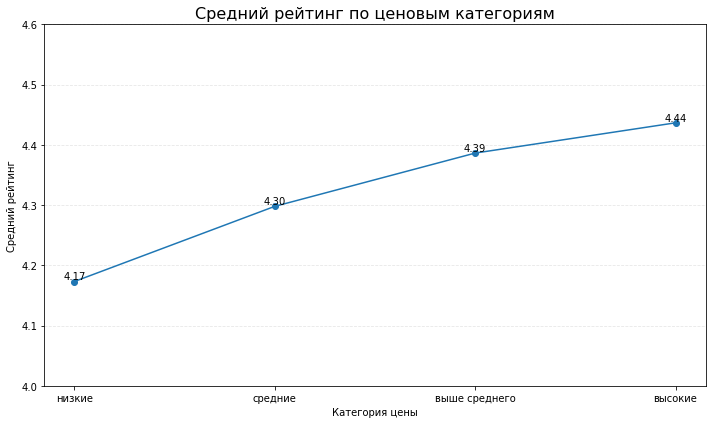

In [74]:
# Порядок категорий
price_order = ['низкие', 'средние', 'выше среднего', 'высокие']

# Готовим данные в нужном порядке
plot_data = (
    price_rating_stats
    .set_index('price')
    .loc[price_order]
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    plot_data['price'],
    plot_data['mean'],
    marker='o'
)

# Подписи точек
for i, value in enumerate(plot_data['mean']):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.title('Средний рейтинг по ценовым категориям', fontsize=16)
plt.xlabel('Категория цены')
plt.ylabel('Средний рейтинг')
plt.ylim(4.0, 4.6)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

По линейному графику видно, что при переходе от низкого ценового сегмента к высокому средний рейтинг заведений постепенно увеличивается:

- **низкие — 4.17**

- средние — 4.30

- выше среднего — 4.39

- **высокие — 4.44**

Наблюдается положительная зависимость: **более дорогие заведения** в среднем получают **более высокие оценки**.

Однако важно учитывать силу этой связи: **Разница** между крайними категориями составляет **всего 0.27 балла**.

Все значения находятся в узком диапазоне 4.17–4.44

Даже недорогие заведения имеют высокий средний рейтинг

<a id='chapter3.7'></a>
### 3.7. Топ-15 популярных сетей в Москве
Выделим 15 крупнейших сетей Москвы по количеству точек, чтобы оценить их влияние на рынок. 

Проанализируем их средние рейтинги и определим, в каких категориях (например, кофейни или фастфуд) сетевой бизнес доминирует успешнее всего. Визуализация поможет наглядно сравнить лидеров рынка и понять, коррелирует ли масштаб сети с качеством сервиса.

In [75]:
# Группируем данные и находим топ-15 сетей
top_15_chains = (
    rest_full[rest_full['chain'] == 1]
    .groupby('name')
    .agg(
        total_places=('name', 'count'), # Считаем количество точек
        avg_rating=('rating', 'mean'),  # Считаем средний рейтинг
        category=('category', lambda x: x.mode()[0]) # Определяем основную категорию
    )
    .sort_values(by='total_places', ascending=False)
    .head(15)
)

# Форматируем названия: первая буква заглавная
top_15_chains = top_15_chains.reset_index()
top_15_chains['name'] = top_15_chains['name'].str.capitalize()

# Округляем рейтинг до 2 знаков
top_15_chains['avg_rating'] = top_15_chains['avg_rating'].round(2)

# Настраиваем индекс, чтобы он начинался с 1
top_15_chains.index = top_15_chains.index + 1

# Вывод итоговой таблицы
top_15_chains

,name,total_places,avg_rating,category
1,Шоколадница,120,4.18,кофейня
2,Домино'с пицца,76,4.17,пиццерия
3,Додо пицца,74,4.29,пиццерия
4,One price coffee,71,4.06,кофейня
5,Яндекс лавка,69,3.87,ресторан
6,Cofix,65,4.08,кофейня
7,Prime,50,4.12,ресторан
8,Хинкальная,44,4.32,кафе
9,Кофепорт,42,4.15,кофейня
10,Кулинарная лавка братьев караваевых,39,4.39,кафе


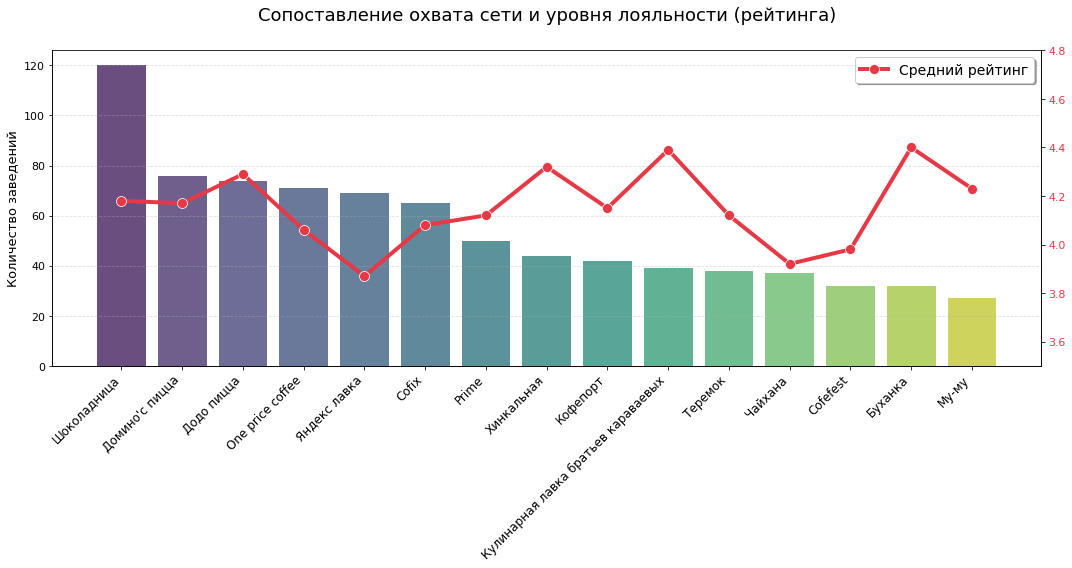

In [76]:
# Подготовим полотно
fig, ax1 = plt.subplots(figsize=(15, 8))

# Построим столбчатую диаграмму (количество заведений)
sns.barplot(
    x='name', 
    y='total_places', 
    data=top_15_chains, 
    ax=ax1, 
    palette='viridis', 
    alpha=0.8
)

# Настройка левой оси и заголовка
ax1.set_title('Сопоставление охвата сети и уровня лояльности (рейтинга)', fontsize=18, pad=30)
ax1.set_ylabel('Количество заведений', fontsize=13)
ax1.set_xlabel('') 

# Настройка подписей категорий
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax1.tick_params(axis='y', labelsize=11)

# Создание второй оси Y для рейтинга (справа)
ax2 = ax1.twinx()

# Построение линейного графика
sns.lineplot(
    x='name', 
    y='avg_rating', 
    data=top_15_chains, 
    ax=ax2, 
    color='#e63946', 
    marker='o', 
    linewidth=4, 
    markersize=10,
    label='Средний рейтинг',
    sort=False 
)

# Настройка правой оси Y
ax2.set_ylabel('') 
ax2.tick_params(axis='y', labelcolor='#e63946', labelsize=11)
ax2.set_ylim(3.5, 4.8)

ax1.grid(axis='y', linestyle='--', alpha=0.4) 
sns.despine(ax=ax1, top=True, right=False) # Оставляем правую ось для рейтинга    

# Настройка легенды
ax2.legend(
    loc='upper right', 
    fontsize=14, 
    title_fontsize=15, 
    frameon=True, 
    shadow=True
)

plt.tight_layout()
plt.show()

Анализ топ-15 сетей Москвы показывает классическую рыночную ситуацию: **масштаб не гарантирует качество**.

- **Связь масштаба и рейтинга**. У самых крупных игроков (**«Шоколадница»**, 120 точек, **кофейня**) средний рейтинг составляет **4.18**. При расширении сети свыше **70–100 объектов** удерживать высокие оценки становится сложнее.
- **Высокие оценки у средних сетей**. Наиболее высокий рейтинг (**4.3–4.4**) зафиксирован у сетей с количеством **точек от 30 до 45**. Это «Буханка» (булочная), «Кулинарная лавка братьев Караваевых» (кафе) и «Хинкальная» (кафе).
- **Самые низкие** показатели в списке у **«Яндекс Лавки» (3.87, категория ресторан/доставка)** и сети **«Чайхана» (3.92, кафе)**. Это указывает на сложности с качеством сервиса в данных сегментах.
- **Устойчивый результат в пиццериях**. Среди крупных сетей (**более 70 точек**) стабильный рейтинг **выше 4.2** удерживает только **«Додо Пицца»** (пиццерия).

**Вывод**:

Наиболее **стабильными по качеству** форматами для сетевого развития в Москве являются **пекарни и кафе-кулинарии**. При росте до 40–50 объектов эти категории позволяют сохранять рейтинг выше 4.3, в то время как в сегменте кофеен и быстрой еды оценки чаще снижаются.

<a id='chapter3.8'></a>
### 3.8. Анализ среднего чека в зависимости от района и удалённости от центра

В данном разделе исследуем, как изменяется средний чек (`middle_avg_bill`) в зависимости от административного округа Москвы. 

Отдельно проанализируем Центральный административный округ (ЦАО) и сравним его с остальными районами. Также проверим влияние выбросов, чтобы результаты были корректными и устойчивыми.

In [77]:
# Посмотрим описательную статистики
rest_full['middle_avg_bill'].describe()

count     3148.000000
mean       958.358005
std       1009.748800
min         30.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Полученные статистические данные указывают на значительный разброс цен: при медиане в 750 рублей максимальный чек достигает внушительных 35 000 рублей, что говорит о наличии выраженного премиального сегмента. Чтобы наглядно увидеть границы типичных цен и оценить масштаб влияния дорогих заведений на общую картину, перейдем к графическому анализу.

Изучим распределение среднего чека в заведениях Москвы с помощью диаграммы размаха (boxplot). Это позволит нам наглядно определить медианную стоимость среднего чека, типичный ценовой диапазон большинства мест и выявить наличие премиальных сегментов с аномально высокими ценами:

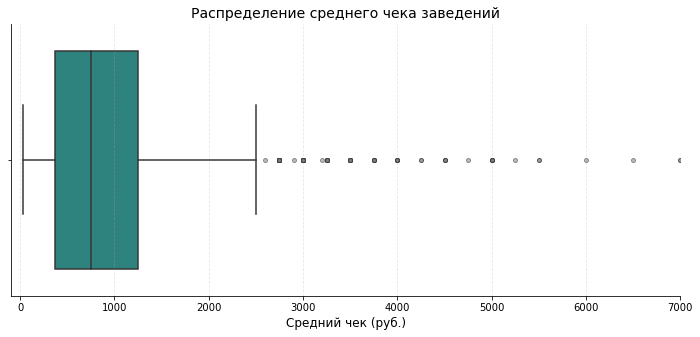

In [78]:
# Устанавливаем размер полотна 
plt.figure(figsize=(12, 5))

# Строим горизонтальный boxplot для среднего чека
sns.boxplot(
    x=rest_full['middle_avg_bill'],
    color='#21918c',      
    flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 4, 'alpha': 0.5}
)

# Оформление графика
plt.title('Распределение среднего чека заведений', fontsize=14)
plt.xlabel('Средний чек (руб.)', fontsize=12)

# Ограничиваем ось X, чтобы лучше видеть "ящик". 
# Значение 5000-7000 обычно достаточно для Москвы, подправьте под свои данные.
plt.xlim(-100, 7000) 

plt.grid(axis='x', linestyle='--', alpha=0.3)

# Удаляем лишние границы
sns.despine()

plt.show()

**Распределение среднего чека**

**Типичный чек**: Большинство заведений Москвы имеют средний чек в диапазоне **от 500 до 1250 рублей** (межквартильный размах). 

**Медианное значение** находится на уровне примерно **750–800 рублей**.

**Нижний порог**: Заведений с чеком **ниже 300 рублей** крайне мало, что ожидаемо для столичного общепита.

**Хвост распределения**: График сильно вытянут вправо. Всё, что выше 2500 рублей, статистически считается выбросами (аномалиями). Это могут быть элитные рестораны, банкетные залы или заведения с эксклюзивной кухней.

Основная масса точек-выбросов сосредоточена в диапазоне 2500–5000 рублей, однако есть единичные «экстремальные» значения (максимальное значени `middle_avg_bill]` - 35 000 руб.).

Вычислим верхнюю границу «усов» (1.5 межквартильных размаха) и отберем заведения, чей средний чек превышает это значение. Выведем 15 самых дорогих из них с указанием округов:

In [79]:
# Рассчитаем границы
q1 = rest_full['middle_avg_bill'].quantile(0.25)
q3 = rest_full['middle_avg_bill'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# Фильтруем заведения выше границы
top_expensive = rest_full[rest_full['middle_avg_bill'] > upper_bound]\
                .sort_values(by='middle_avg_bill', ascending=False)

print(f"Верхняя граница «усов»: {upper_bound:.0f} руб.")
print(f"Количество заведений-выбросов (выше границы): {len(top_expensive)}") 

# Вывод первых 15 строк
display(top_expensive[['name', 'district', 'middle_avg_bill']].head(15)) 

Верхняя граница «усов»: 2562 руб.
Количество заведений-выбросов (выше границы): 104


,name,district,middle_avg_bill
7173,кафе,южный административный округ,35000.0
729,чойхона,северный административный округ,11000.0
5477,гости,восточный административный округ,10000.0
3878,white rabbit,центральный административный округ,7250.0
3392,марио,центральный административный округ,7000.0
3483,800°с contemporary steak,центральный административный округ,7000.0
3514,чайка,центральный административный округ,6500.0
3906,кантинетта антинори,центральный административный округ,6000.0
2792,крошка картошка,восточный административный округ,5500.0
3599,lucky izakaya bar,центральный административный округ,5500.0


Основная концентрация приходится на **ЦАО**.

Высокий чек может быть обусловлен премиальным расположением, авторской кухней, эксклюзивным сервисом или форматом (банкетные залы, элитные клубы). 

Чек в 35 000 руб. для заведения с общим названием «Кафе» в ЮАО и 10 000 руб. для "Гости" выглядят в ВАО как типичная ошибка ввода данных (опечатка в лишний ноль) или внесение в базу общей суммы за банкет вместо чека на одного гостя.

Высокие значения у сетевых точек (например, «Крошка Картошка» — 5 500 руб., сюда же можно отнести "чойхону" с возможной опечаткой) указывают на ошибки в данных (лишние нули при вводе) или специфику учета (сумма банкета вместо чека на одного). Изучим сетевые заведения с высоким чеком:

In [80]:
# Фильтруем только сетевые заведения
chains = rest_full[rest_full['chain'] == 1]

# Считаем среднее, медиану и максимум для каждой сети
chain_stats = chains.groupby('name')['middle_avg_bill'].agg(['mean', 'median', 'max', 'count'])

# Находим сети, где максимум сильно оторвался от медианы (например, более чем в 2 раза)
suspicious_chains = chain_stats[chain_stats['max'] > chain_stats['median'] * 3].sort_values(by='max', ascending=False)

display(suspicious_chains.head(10))

,mean,median,max,count
name,,,,
крошка картошка,791.500000,300.0,5500.0,10
phobo,837.500000,500.0,3200.0,8
пшеница,620.000000,310.0,1250.0,3
чайхона айва,591.666667,350.0,1175.0,3


Посмотрим детальную информацию по сетевым точкам "Крошка картошка" и "Phobo":

In [81]:
display( rest_full[rest_full['name'].isin(['крошка картошка', 'phobo'])].sort_values(by='middle_avg_bill', ascending=False))

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
2792,cbc50e386c7f40bab6f669e320d0fbac,крошка картошка,быстрое питание,"щёлковское шоссе, вл75",восточный административный округ,"ежедневно, 10:00–22:00",4.0,1,<NA>,высокие,Средний счёт:1000–10000 ₽,5500.0,NaN,0
4265,bb1a7d863cd9491e9db621dc115debff,phobo,быстрое питание,"улица арбат, 13",центральный административный округ,"ежедневно, 11:00–23:00",4.2,1,20,высокие,Средний счёт:400–6000 ₽,3200.0,NaN,0
4189,2fefc670da444b11b1bf162bdf5a75f7,phobo,быстрое питание,"площадь киевского вокзала, 2",западный административный округ,"ежедневно, 10:00–22:00",3.9,1,300,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
4336,7b5ea9006caa4dd0b9c380a7cf711f77,phobo,быстрое питание,"нижний сусальный переулок, 5, стр. 1",центральный административный округ,"ежедневно, 11:00–23:00",4.3,1,95,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
7733,e1705628b3b146868d123b4bf0605097,phobo,быстрое питание,"варшавское шоссе, 140",южный административный округ,"ежедневно, 10:00–22:00",3.2,1,<NA>,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
1530,26232fc2b73a4fbc90c90d7c81c4c2f1,phobo,быстрое питание,"ленинградское шоссе, 16а, стр. 4",северный административный округ,"ежедневно, 10:00–23:00",3.9,1,230,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
1577,bbfed7e7565c4d2cb010c91fdcd2210a,phobo,быстрое питание,"хорошёвское шоссе, 27",северный административный округ,"ежедневно, 10:00–22:00",3.5,1,45,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
2662,096f50c4396148b38c962e2ab870d178,phobo,быстрое питание,"щёлковское шоссе, вл75",восточный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.2,1,<NA>,средние,Средний счёт:400–600 ₽,500.0,NaN,0
5838,f8bc683e2f364209a329c0dfefd9186d,phobo,быстрое питание,"проспект вернадского, 6",западный административный округ,"ежедневно, 10:00–22:00",3.8,1,180,средние,Средний счёт:400–600 ₽,500.0,NaN,0
3361,06636b6673a2472dbce41a58995edb76,крошка картошка,быстрое питание,"кутузовский проспект, 57",западный административный округ,"ежедневно, 10:00–22:00",3.9,1,96,средние,Средний счёт:300–350 ₽,325.0,NaN,0


Из таблицы видно, что это ошибка в данных, а именно лишний ноль в конце. Удалим его и заменим значение категории цен соответственно:

In [82]:
# Исправляем Крошку Картошку (5500 -> 550) и меняем категорию на 'средние'
rest_full.loc[
    (rest_full['name'] == 'крошка картошка') & (rest_full['middle_avg_bill'] == 5500), 
    ['middle_avg_bill', 'price']
] = [550, 'средние']

# Исправляем Phobo (3200 -> 320) и меняем категорию на 'средние'
rest_full.loc[
    (rest_full['name'] == 'phobo') & (rest_full['middle_avg_bill'] == 3200), 
    ['middle_avg_bill', 'price']
] = [320, 'средние']

# Проверяем результат: фильтруем по именам и сортируем по убыванию чека
display(
    rest_full[rest_full['name'].isin(['крошка картошка', 'phobo'])]
    .sort_values(by='middle_avg_bill', ascending=False)
)


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
2792,cbc50e386c7f40bab6f669e320d0fbac,крошка картошка,быстрое питание,"щёлковское шоссе, вл75",восточный административный округ,"ежедневно, 10:00–22:00",4.0,1,<NA>,средние,Средний счёт:1000–10000 ₽,550.0,NaN,0
4189,2fefc670da444b11b1bf162bdf5a75f7,phobo,быстрое питание,"площадь киевского вокзала, 2",западный административный округ,"ежедневно, 10:00–22:00",3.9,1,300,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
4336,7b5ea9006caa4dd0b9c380a7cf711f77,phobo,быстрое питание,"нижний сусальный переулок, 5, стр. 1",центральный административный округ,"ежедневно, 11:00–23:00",4.3,1,95,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
7733,e1705628b3b146868d123b4bf0605097,phobo,быстрое питание,"варшавское шоссе, 140",южный административный округ,"ежедневно, 10:00–22:00",3.2,1,<NA>,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
1530,26232fc2b73a4fbc90c90d7c81c4c2f1,phobo,быстрое питание,"ленинградское шоссе, 16а, стр. 4",северный административный округ,"ежедневно, 10:00–23:00",3.9,1,230,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
1577,bbfed7e7565c4d2cb010c91fdcd2210a,phobo,быстрое питание,"хорошёвское шоссе, 27",северный административный округ,"ежедневно, 10:00–22:00",3.5,1,45,NaN,Средний счёт:400–600 ₽,500.0,NaN,0
2662,096f50c4396148b38c962e2ab870d178,phobo,быстрое питание,"щёлковское шоссе, вл75",восточный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.2,1,<NA>,средние,Средний счёт:400–600 ₽,500.0,NaN,0
5838,f8bc683e2f364209a329c0dfefd9186d,phobo,быстрое питание,"проспект вернадского, 6",западный административный округ,"ежедневно, 10:00–22:00",3.8,1,180,средние,Средний счёт:400–600 ₽,500.0,NaN,0
3361,06636b6673a2472dbce41a58995edb76,крошка картошка,быстрое питание,"кутузовский проспект, 57",западный административный округ,"ежедневно, 10:00–22:00",3.9,1,96,средние,Средний счёт:300–350 ₽,325.0,NaN,0
4265,bb1a7d863cd9491e9db621dc115debff,phobo,быстрое питание,"улица арбат, 13",центральный административный округ,"ежедневно, 11:00–23:00",4.2,1,20,средние,Средний счёт:400–6000 ₽,320.0,NaN,0


In [83]:
# Фильтруем строки, где в названии есть "чойхона" или "чайхона"
target_places = rest_full[rest_full['name'].str.contains('чайхона|чойхона', case=False, na=False)]

# Фильтруем, сортируем по убыванию чека и выводим первые 5 строк
display(
    target_places[['name', 'district', 'address', 'middle_avg_bill', 'price']]
    .sort_values(by='middle_avg_bill', ascending=False)
    .head(5)
)

,name,district,address,middle_avg_bill,price
729,чойхона,северный административный округ,"дмитровское шоссе, 95а",11000.0,высокие
3711,чайхона №1,центральный административный округ,"улица новый арбат, 21",2000.0,высокие
5399,чайхона № 1,восточный административный округ,"городецкая улица, 5",1750.0,NaN
338,чайхона № 1,северо-западный административный округ,"лодочная улица, 4",1750.0,высокие
682,чайхона №1,северо-восточный административный округ,"алтуфьевское шоссе, 16",1750.0,высокие


- Исправим опечатку в названии («чойхона»  на «чайхона»).
- Уберем лишний ноль в чеке (11 000 -> 1 100).
- Понизим категорию цены («высокие» -> «выше среднего»), так как чек в 1100 руб. 

In [84]:
# Исправляем название, чек и категорию для аномальной Чойхоны
rest_full.loc[
    (rest_full['name'].str.contains('чойхона', case=False)) & (rest_full['middle_avg_bill'] == 11000), 
    ['name', 'middle_avg_bill', 'price']
] = ['чайхона', 1100, 'выше среднего']


# Проверяем результат по названию "чайхона"
display(rest_full[(rest_full['name'].str.contains('чайхона', case=False))
    ].sort_values(by='middle_avg_bill', ascending=False)
)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
3711,98e73b9d6b1f4a269d5fb20a69b7de61,чайхона №1,ресторан,"улица новый арбат, 21",центральный административный округ,"ежедневно, 10:00–06:00",4.4,1,287,высокие,Средний счёт:2000 ₽,2000.0,NaN,0
5399,90ce83e1f03a4f19b1fcc4bc048a842f,чайхона № 1,ресторан,"городецкая улица, 5",восточный административный округ,"пн-чт 11:00–00:00; пт,сб 11:00–02:00; вс 11:00...",4.4,1,125,NaN,Средний счёт:1500–2000 ₽,1750.0,NaN,0
338,817262f0b6db4b5a9cf1b7250a2009b4,чайхона № 1,ресторан,"лодочная улица, 4",северо-западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.5,1,166,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,0
682,1a84ffb61a404b9fb82a01b3d2102840,чайхона №1,ресторан,"алтуфьевское шоссе, 16",северо-восточный административный округ,"ежедневно, 12:00–06:00",4.4,1,310,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,0
6904,eaac8f0c2396457fa07430f4f2eb14e0,чайхона №1,ресторан,"улица бутлерова, 22",юго-западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.4,1,159,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,0
6556,ad04dd365c1c4ae68f835dc3f1160687,чайхона №1,ресторан,"проспект вернадского, 105, корп. 3",западный административный округ,"ежедневно, 11:00–02:00",4.4,1,250,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,0
5869,5f2360d5c34c4b2c8d16cd4a1a06b643,чайхона нурман,ресторан,"проспект вернадского, 11/19",юго-западный административный округ,"ежедневно, 11:00–00:00",4.0,0,50,выше среднего,Средний счёт:1000–2000 ₽,1500.0,NaN,0
7316,b4afa714a0b74fdd86d3b9ea7ddac60b,чайхона № 1,ресторан,"люблинская улица, 96",юго-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.4,1,99,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN,0
3706,9669eb0d7c204871819470a2f335b429,чайхона № 1,ресторан,"1-я тверская-ямская улица, 7",центральный административный округ,"ежедневно, 11:00–06:00",4.3,1,320,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN,0
4929,f5657bbaa7c04c3ea36a28415b17b447,чайхона айва,кафе,"павелецкая площадь, 1",центральный административный округ,"ежедневно, круглосуточно",4.4,1,150,выше среднего,Средний счёт:350–2000 ₽,1175.0,NaN,1


Удалим "Кафе" в ЮАО и заведение "Гости" по индексам. Значения чеков в 35 000 руб. и 10 000 руб. соответственно являются явными техническими ошибками (лишний ноль или стоимость банкета), которые критически искажают общую статистику по округам:

In [85]:
# Удаляем строки по индексам
rest_full = rest_full.drop(index=[7173, 5477])

# Выводим кол-во строк датафрейма
print(f"Очистка завершена. Удалено 2 критических выброса. Текущий размер датафрейма: {len(rest_full)}")


Очистка завершена. Удалено 2 критических выброса. Текущий размер датафрейма: 8400


Визуализируем топ-15 самых дорогих заведений по округам после очистки, чтобы наглядно увидеть ценовых лидеров Москвы и географическую концентрацию наиболее дорогих локаций:


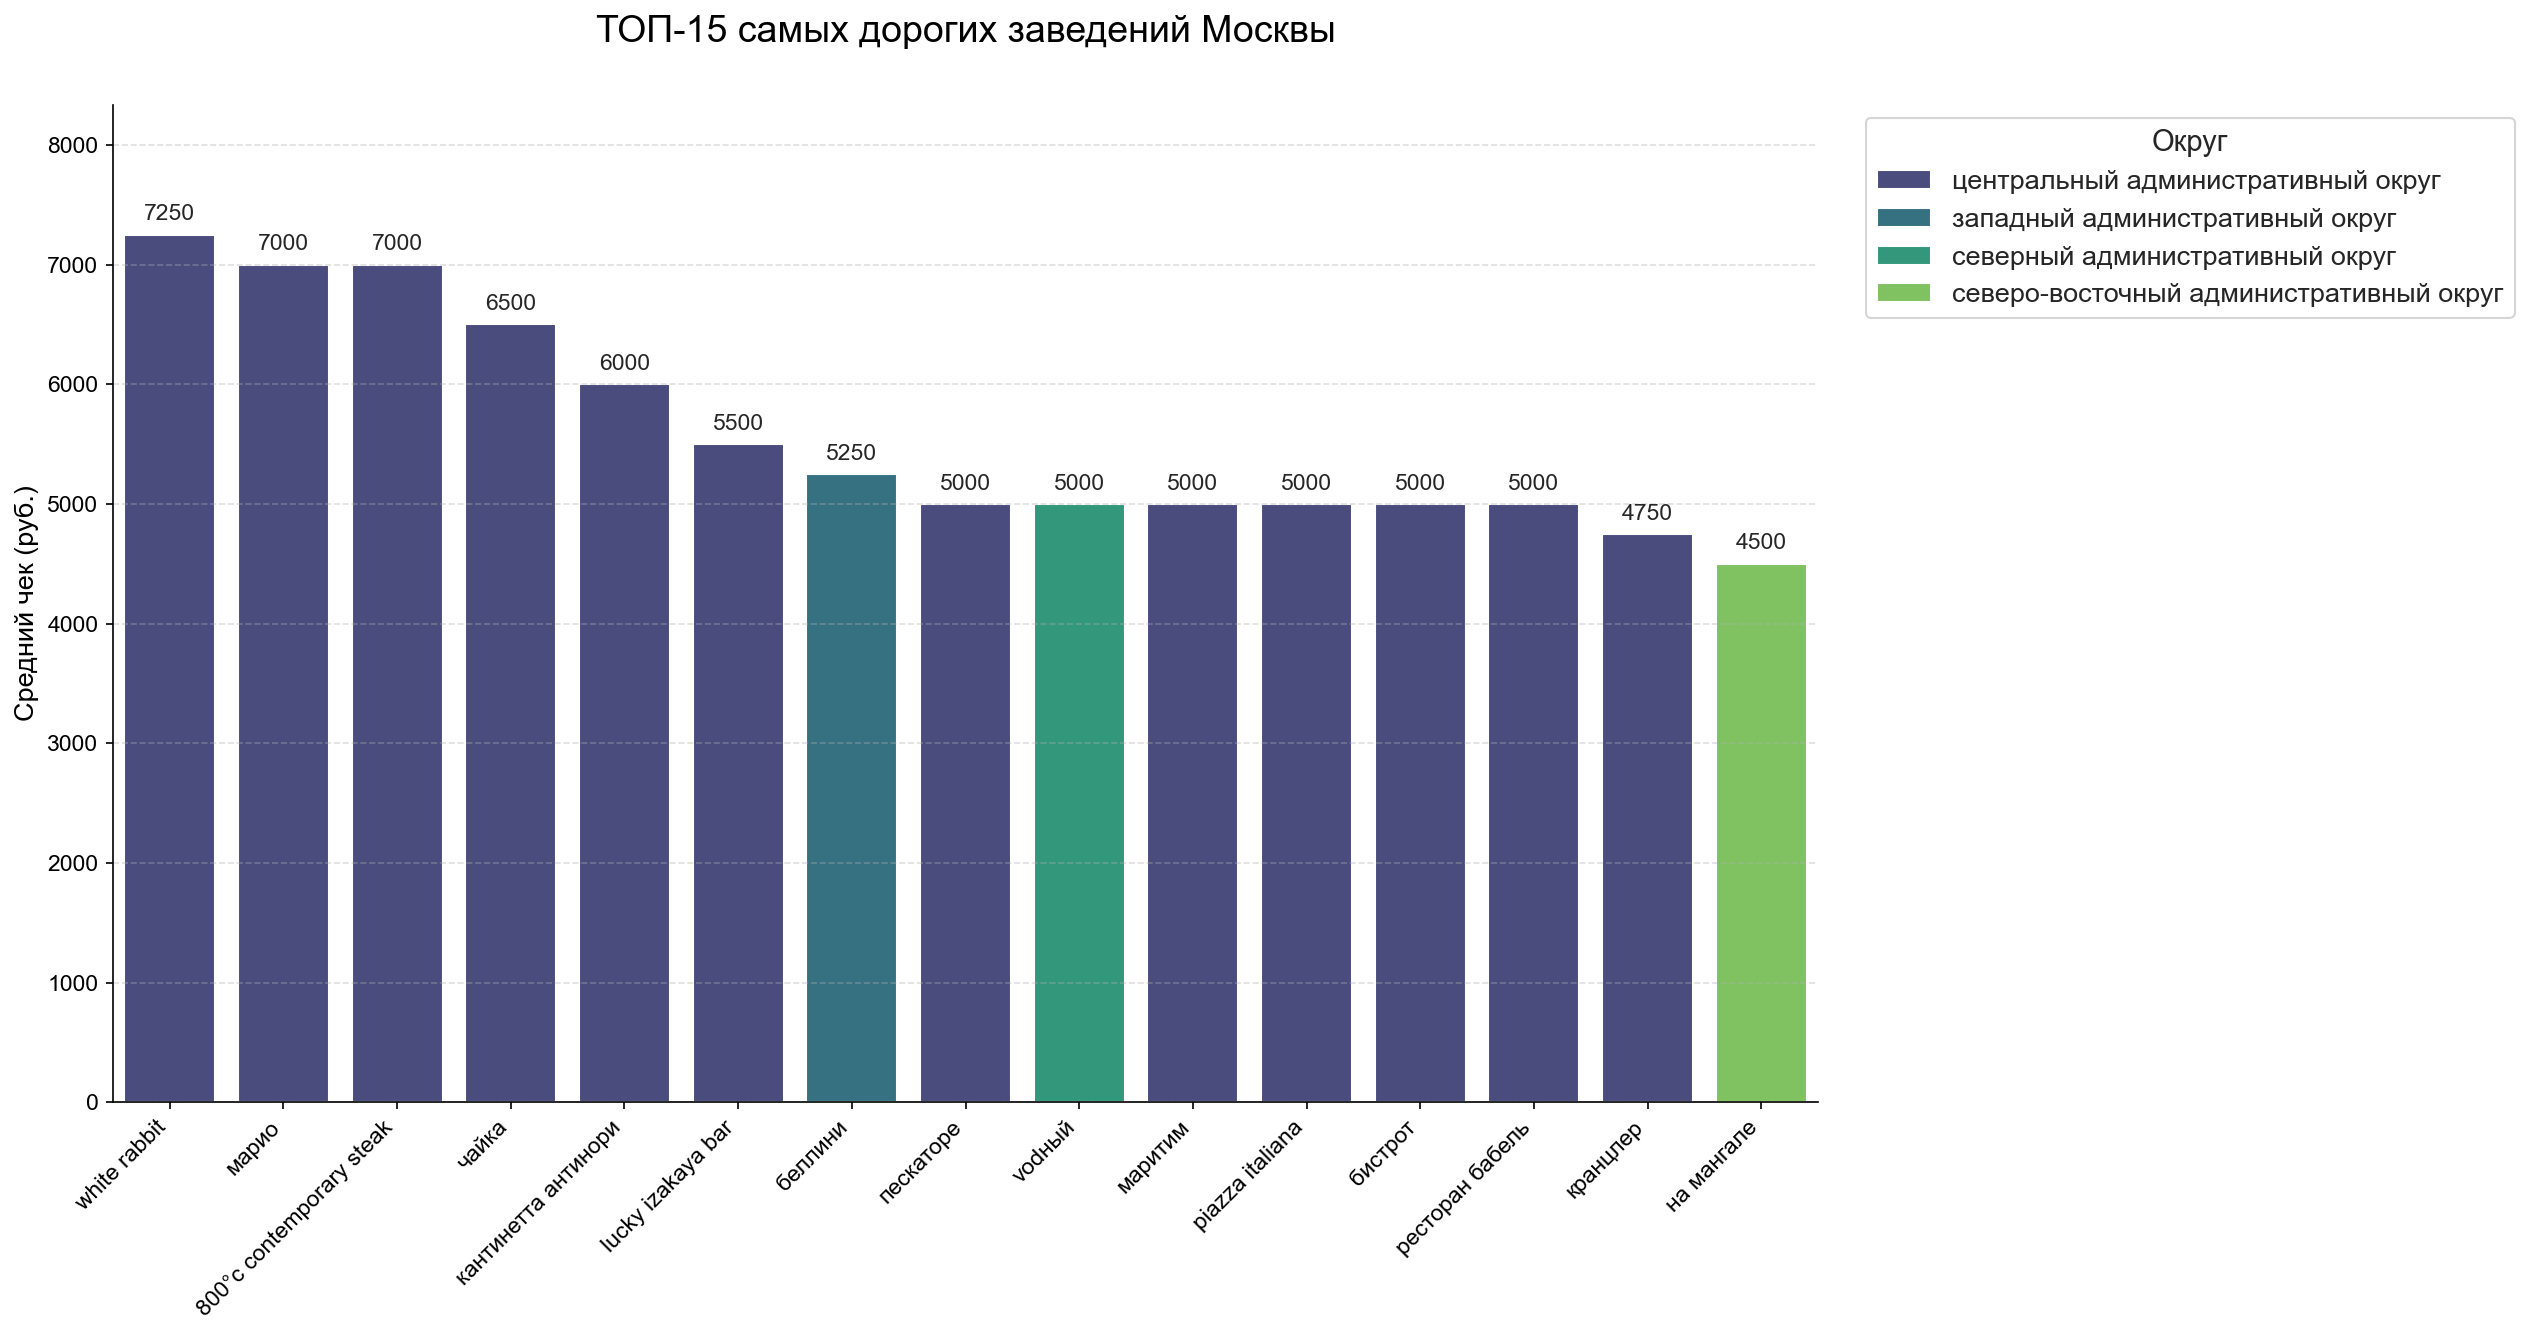

In [86]:
# Отбираем ТОП-15 самых дорогих заведений
top_15_data = (
    rest_full
    .sort_values(by='middle_avg_bill', ascending=False)
    .head(15)
)

# Настраиваем полотно
fig, ax = plt.subplots(figsize=(17, 9), dpi=150)
sns.set_style("white") 

# Строим график
sns.barplot(
    x='name', 
    y='middle_avg_bill', 
    data=top_15_data, 
    hue='district', 
    dodge=False,     
    palette='viridis',
    ax=ax 
)

# Добавляем значения 
for p in ax.patches:
    height = p.get_height()
    # height == height отсекает NaN, height > 0 отсекает пустые бары от hue
    if height == height and height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=11)

# Оформление заголовка и осей
ax.set_title('ТОП-15 самых дорогих заведений Москвы', fontsize=18, pad=30)
ax.set_ylabel('Средний чек (руб.)', fontsize=13)
ax.set_xlabel('')

# Настройка подписей заведений
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Масштаб оси Y
ax.set_ylim(0, top_15_data['middle_avg_bill'].max() * 1.15)

# Настраиваем легенду
ax.legend(
    title='Округ', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    fontsize=13, 
    title_fontsize=14,
    frameon=True
)

ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()


После очистки данных от экстремальных выбросов и исправления технических ошибок в сетевых заведениях («Крошка Картошка» и Phobo), визуализация приняла реалистичный вид:

Как и предполагалось, **лидером** является Центральный административный округ (**ЦАО**). Здесь сосредоточено подавляющее большинство заведений с чеком **выше 5 000 рублей**, включая флагманский **White Rabbit**.

Остальные округа представлены лишь единичными премиальными локациями (например, в ЗАО и САО), что подтверждает статус центра как главной зоны элитного гастрономического потребления Москвы.

Единственным представителем СВАО в топ-15 стало заведение «На мангале», что выделяет его как уникальную премиальную точку для данного округа.

Очистка данных позволила увидеть реальную картину, где элитный сегмент жестко привязан к историческому центру и престижным западным направлениям.

Визуализируем структуру ценовых категорий (по столбцу `price`) в каждом округе, чтобы сравнить распределение заведений по уровню цен и выявить доминирующие сегменты рынка по категориям цен (низкие, средние, выше среднего и т.д.). Чтобы сделать визуализацию компактной, используем замену полных названий округов на общепринятые аббревиатуры:

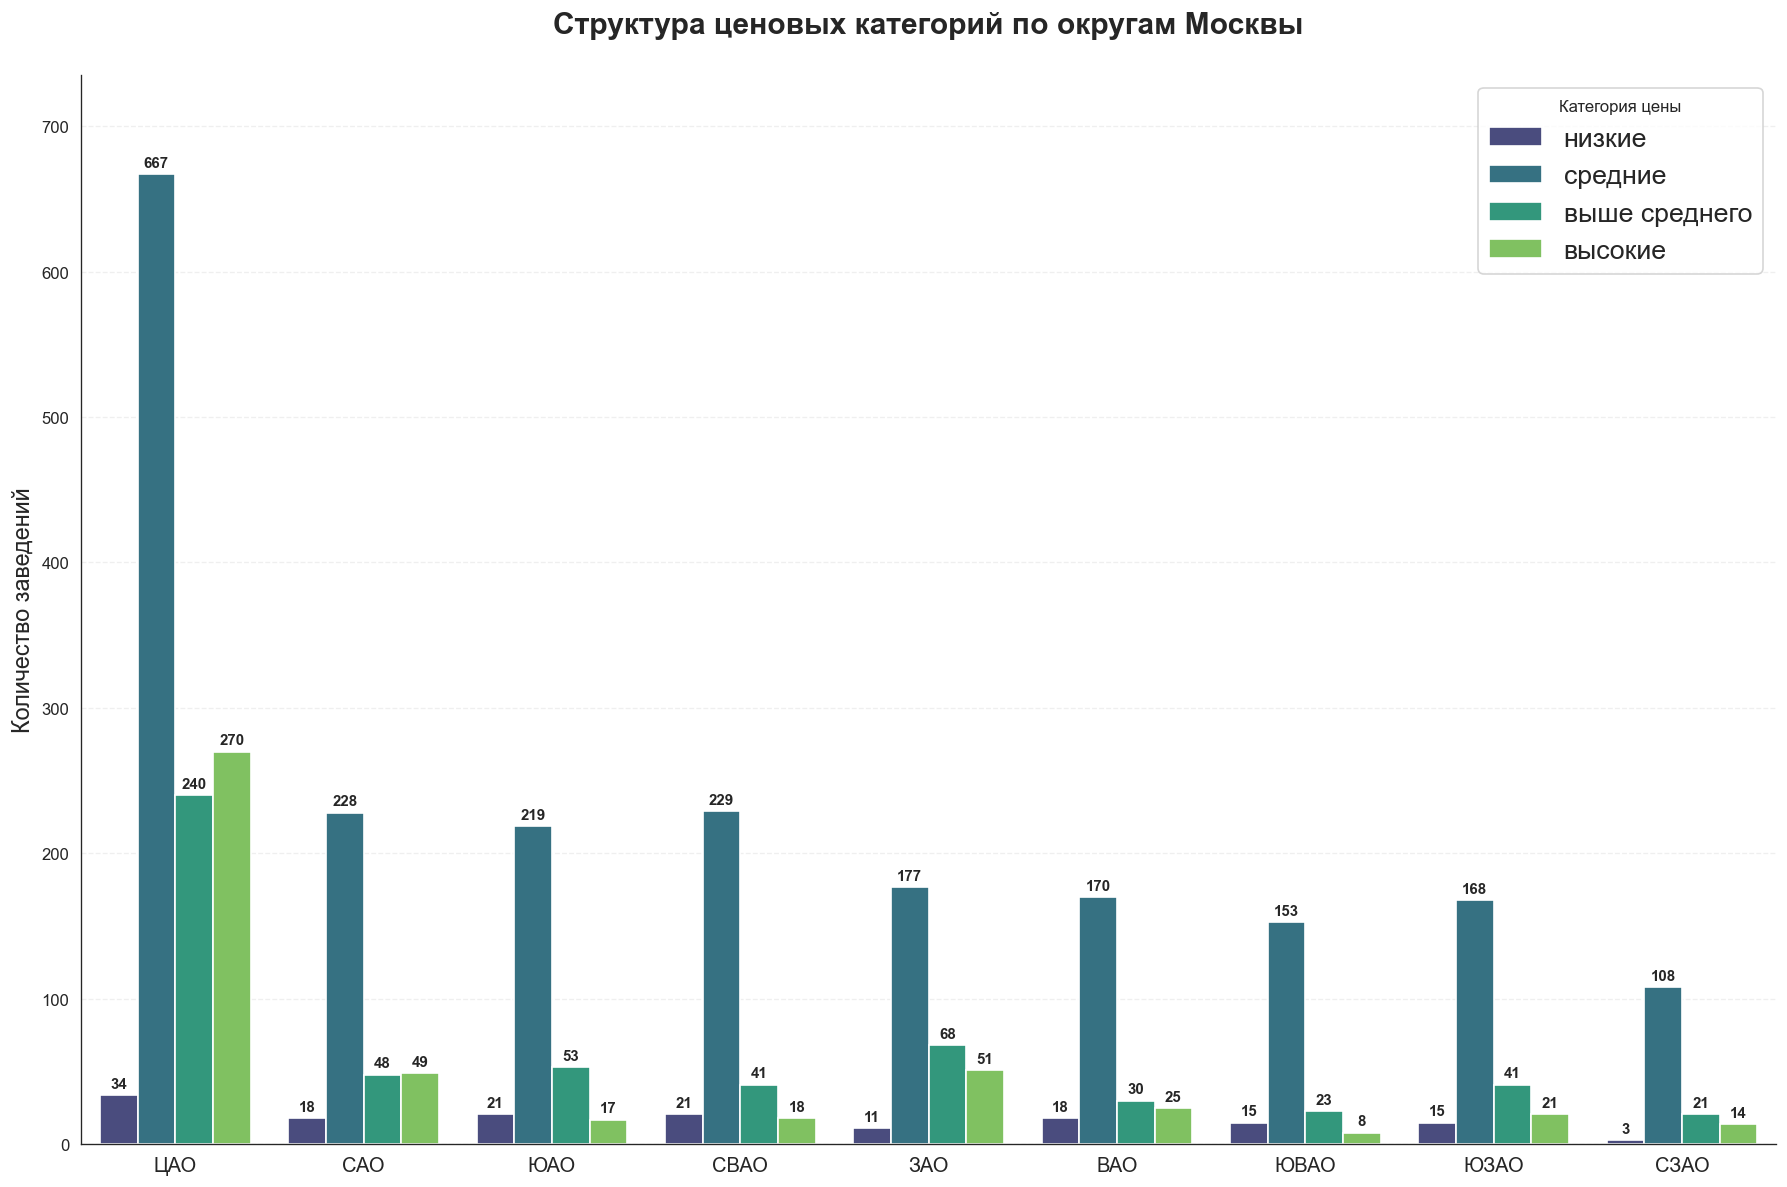

In [87]:
# Создаем словарь для замены названий на аббревиатуры
district_mapping = {
    'центральный административный округ': 'ЦАО',
    'северный административный округ': 'САО',
    'северо-восточный административный округ': 'СВАО',
    'восточный административный округ': 'ВАО',
    'юго-восточный административный округ': 'ЮВАО',
    'южный административный округ': 'ЮАО',
    'юго-западный административный округ': 'ЮЗАО',
    'западный административный округ': 'ЗАО',
    'северо-западный административный округ': 'СЗАО'
}

# Создаем копию для графика и заменяем названия на аббревиатуры
plot_data = rest_full.copy()
plot_data['district'] = plot_data['district'].map(district_mapping).fillna(plot_data['district'])

# Настраиваем порядок округов и цен
district_order = plot_data['district'].value_counts().index
price_order = ['низкие', 'средние', 'выше среднего', 'высокие']

# Устанавливаем размер полотна и добавим четкость 
plt.figure(figsize=(15, 10), dpi=120) 
sns.set_style("white")

# Строим вертикальный столбчатый график
ax = sns.countplot(
    data=plot_data, 
    x='district', 
    order=district_order, 
    hue='price', 
    hue_order=price_order,
    palette='viridis'
)

# Настраиваем оформления
plt.title('Структура ценовых категорий по округам Москвы', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('')
plt.ylabel('Количество заведений', fontsize=14)
plt.xticks(rotation=0, fontsize=12) 
plt.legend(title='Категория цены', fontsize=16, frameon=True)

# Добавляем подписи значений 
for p in ax.patches:
    height = p.get_height()
    # height == height отсекает NaN, height > 0 отсекает пустые категории
    if height == height and height > 0:
        ax.text(
            p.get_x() + p.get_width()/2., 
            height + 5,
            f'{int(height)}', 
            ha="center", 
            fontsize=9, 
            fontweight='bold'
        )


sns.despine()
ax.grid(axis='y', linestyle='--', alpha=0.3)
# Делаем небольшой запас сверху, чтобы цифры не обрезались
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.show()


Во всех округах основной сегмент — «средние цены».

**ЦАО существенно выделяется**:

- наибольшее количество заведений в категории «высокие»,

- самая высокая концентрация сегмента «выше среднего».

В периферийных округах (СЗАО, ЮВАО и др.) доля дорогих заведений заметно ниже.

В отдельных округах присутствует больше заведений низкого ценового сегмента, чем в центре.

Рассчитаем медиану фактического среднего чека (`middle_avg_bill`) по каждому административному округу и сравним значения между ними, чтобы проверить, действительно ли центр остаётся самым дорогим сегментом. 

In [88]:
# Группируем данные по округам
bill_by_district = (
    rest_full
    .groupby('district')['middle_avg_bill']
    .agg(['mean', 'median', 'count'])
    .sort_values(by='mean', ascending=False)
    .reset_index()
)

bill_by_district

,district,mean,median,count
0,центральный административный округ,1189.462701,1000.0,1059
1,западный административный округ,1053.225490,1000.0,306
2,северный административный округ,897.214286,650.0,322
3,северо-западный административный округ,822.222930,700.0,157
4,юго-западный административный округ,792.561702,600.0,235
5,восточный административный округ,766.073359,550.0,259
6,южный административный округ,725.242812,500.0,313
7,северо-восточный административный округ,716.611296,500.0,301
8,юго-восточный административный округ,654.097938,450.0,194


Проанализировав средние значения чека в цифрах, мы видим заметное лидерство ЦАО и ЗАО. Для наглядного сравнения округов перейдем к графическому анализу:

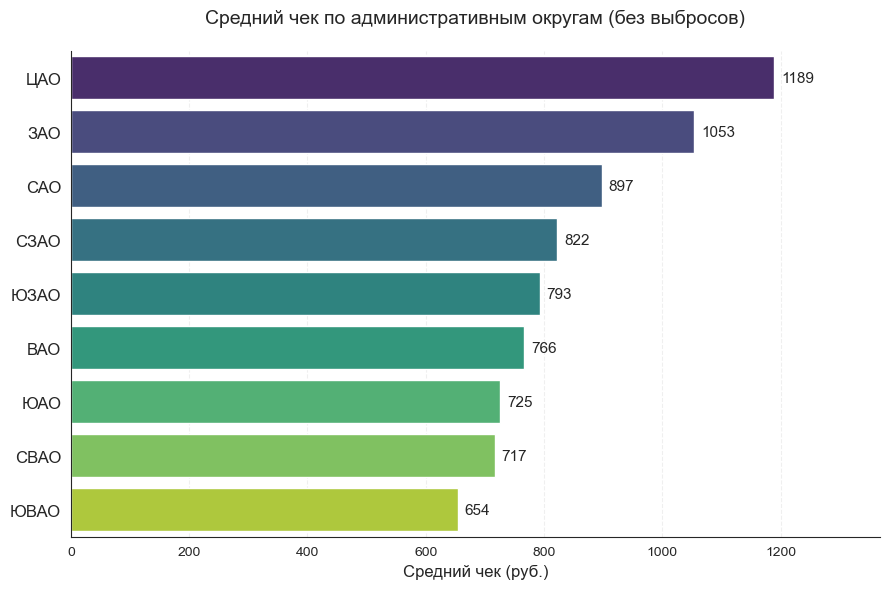

In [89]:
# Устанавливаем dpi для четкости и размер полотна
plt.figure(figsize=(9, 6), dpi=100) 

# Строим график
ax = sns.barplot(
    data=bill_by_district, 
    x='mean', 
    y=bill_by_district['district'].map(district_mapping), 
    hue='district', 
    palette='viridis', 
    dodge=False
)

# Добавляем подписи значений
for p in ax.patches:
    width = p.get_width()
    # Проверка на NaN и исключение пустых значений
    if width == width and width > 0:
        ax.annotate(f'{width:.0f}', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points',
                    fontsize=11)

# Оформление
plt.title('Средний чек по административным округам (без выбросов)', fontsize=14, pad=20)
plt.xlabel('Средний чек (руб.)', fontsize=12)
plt.ylabel('')

# Увеличиваем размер аббревиатур округов (ось Y)
plt.yticks(fontsize=12) 

# Убираем лишнюю легенду
plt.legend([], frameon=False)

# Сетка и очистка границ
plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()

# Запас по оси X, чтобы цифры не вылезали за край
plt.xlim(0, bill_by_district['mean'].max() * 1.15)

plt.tight_layout()
plt.show()


Тенденция к снижению стоимости среднего чека при движении от центра к периферийным округам.

**Максимальный средний чек** зафиксирован в **ЦАО** (**1192 руб.**), **минимальный** — в **ЮВАО** (**654 руб.**).

График и **расчеты делались по медиане**, так как среднее арифметическое (mean) в данном наборе данных подвержено влиянию «выбросов» — единичных заведений с аномально высоким чеком. Медиана дает более объективное представление о типичном чеке для большинства посетителей.

После расчёта медианных значений по каждому административному округу мы видим, что самый высокий типичный чек зафиксирован в ЦАО, а минимальные значения — в удалённых округах. 

Чтобы подтвердить влияние именно фактора «центр / не центр» и оценить масштаб различий, далее агрегируем округа в две группы и проведём их прямое количественное и визуальное сравнение.

In [90]:
# Создаем группировочный признак
rest_full['location_type'] = rest_full['district'].apply(
    lambda x: 'ЦАО' if x == 'центральный административный округ' else 'Другие округа'
)

# Группируем, считаем показатели и округляем до 2-х знаков
stats_table = rest_full.groupby('location_type')['middle_avg_bill'].agg([
    'mean', 
    'median', 
    'count'
]).round(2)


# Сброс индекса и переименование столбцов
stats_table = stats_table.reset_index()
stats_table.columns = ['Расположение', 'Среднее (руб.)', 'Медиана (руб.)', 'Кол-во заведений (n)']

# Вывод результата
print(stats_table)

    Расположение  Среднее (руб.)  Медиана (руб.)  Кол-во заведений (n)
0  Другие округа          811.95           600.0                  2087
1            ЦАО         1189.46          1000.0                  1059


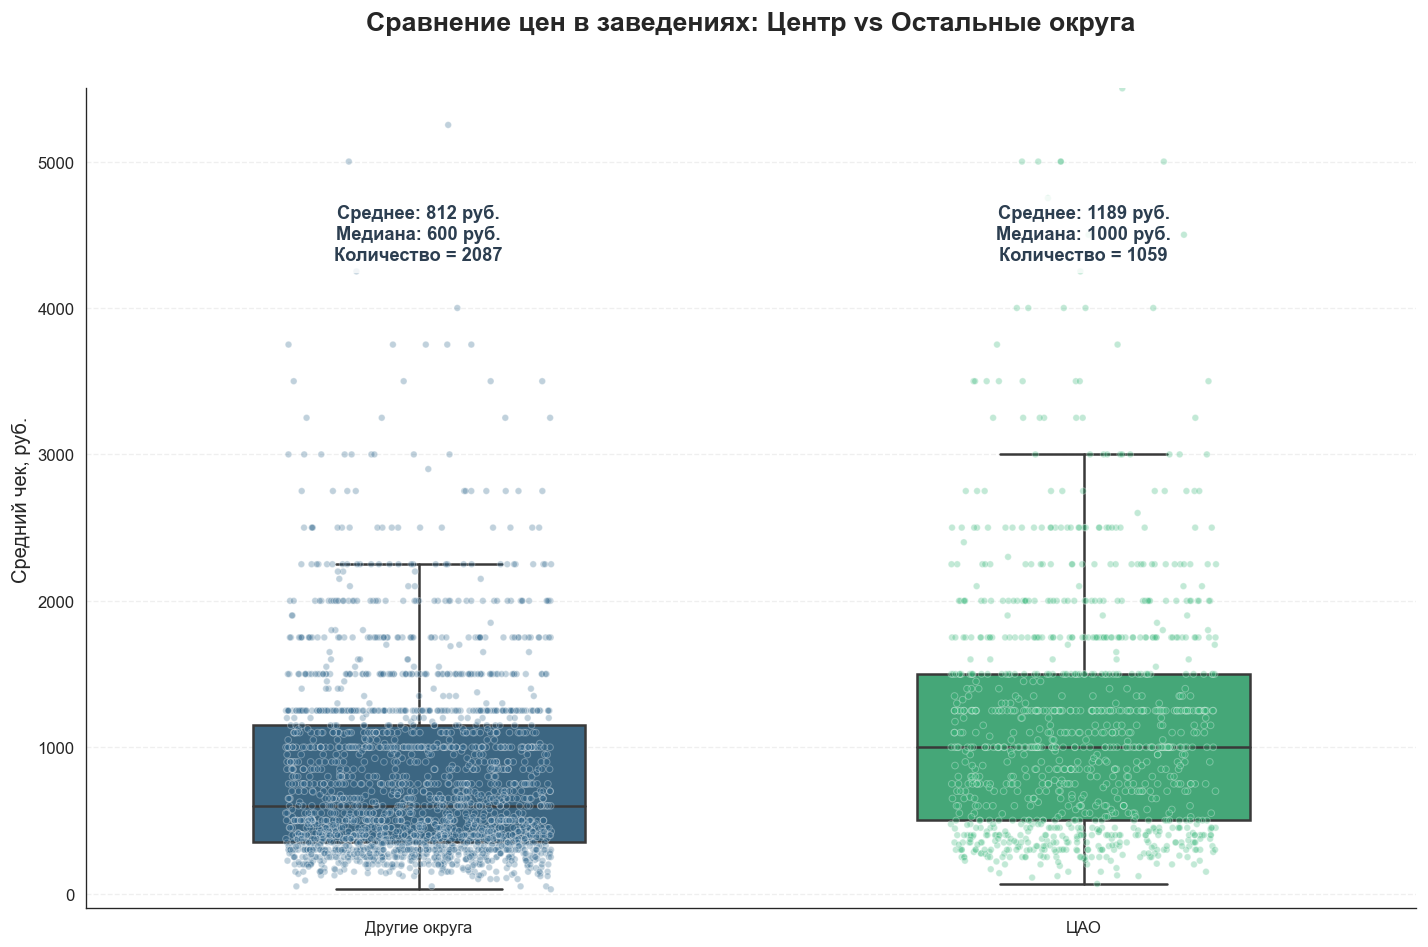

In [91]:
# Настроиваем стиль и устанавливаем размер полотна 
sns.set_style("white")
plt.figure(figsize=(12, 8), dpi=120)

# Строим Boxplot
ax = sns.boxplot(
    data=rest_full, 
    x='location_type', 
    y='middle_avg_bill', 
    palette='viridis', 
    width=0.5,
    showfliers=False, 
    linewidth=1.5,
    zorder=1
)

# Накладываем точки (Stripplot)
sns.stripplot(
    data=rest_full, 
    x='location_type', 
    y='middle_avg_bill', 
    hue='location_type',   
    palette='viridis', 
    alpha=0.3, 
    jitter=0.2,           
    size=4,                
    linewidth=0.6,         
    edgecolor='white',     
    zorder=2               
)

# Удаляем легенду
if ax.get_legend():
    ax.get_legend().remove()

# Выводим аннотации из stats_table
# i — индекс (0, 1), row — данные из таблицы stats_table
for i, row in stats_table.iterrows():
    # Берем названия колонок из вашей stats_table (Расположение, Среднее (руб.), Медиана (руб.), Кол-во заведений (n))
    text = (f"Среднее: {row['Среднее (руб.)']:.0f} руб.\n"
            f"Медиана: {row['Медиана (руб.)']:.0f} руб.\n"
            f"Количество = {int(row['Кол-во заведений (n)'])}")
    
    # Размещаем текст по координате i (соответствует Другие округа / ЦАО)
    plt.text(i, 4300, text, ha='center', va='bottom', 
             fontsize=11, fontweight='bold', color='#2c3e50',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5'))

# Оформление заголовка и осей
plt.title('Сравнение цен в заведениях: Центр vs Остальные округа', 
          fontsize=16, fontweight='bold', pad=35)
plt.ylabel('Средний чек, руб.', fontsize=12)
plt.xlabel('', fontsize=12)

plt.ylim(-100, 5500)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


График наглядно подтверждает существенный ценовой разрыв между ЦАО и остальными административными округами Москвы:

**Значительная разница в типичном чеке**: 
Медианная стоимость в центре составляет 1000 руб., что на 67% выше, чем в других округах (600 руб.). Это говорит о том, что даже «обычное» заведение в центре обойдется заметно дороже.

«Коробка» (межквартильный размах) ЦАО расположена выше: 75% заведений в центре имеют чек выше, чем медиана в остальных округах.

В других округах основная масса заведений сосредоточена в бюджетном сегменте до 1000–1200 руб.
**Концентрация премиального сегмента**: Облако точек (stripplot) в ЦАО значительно плотнее в высоком диапазоне (3000–5000 руб.).

В центре Москвы не только выше средний чек (1192 руб. против 823 руб.), но и гораздо шире представлен выбор дорогих заведений.

**Масштаб рынка**: Несмотря на более высокие цены, ЦАО аккумулирует в себе около трети всех исследуемых заведений (1059 из 3147), что подчеркивает сверхвысокую концентрацию ресторанного бизнеса в центре.

**Итог**: ЦАО является зоной с премиальным ценообразованием и широким разбросом цен. По мере удаления от центра рынок становится более однородным, ориентированным на массовый сегмент с более низким и предсказуемым чеком.

<a id='chapter4'></a>
## 4. Итоговый вывод и рекомендации

В ходе исследования был проведён комплексный анализ рынка общественного питания Москвы на основе объединённого датафрейма `rest_full`. 

Работа включала этап предобработки данных (очистка пропусков, устранение аномалий, унификация текстовых полей, удаление дубликатов), а также исследовательский анализ рынка общественного питания Москвы:
- изучили структуру 8400 заведений, распределение по округам, ценовые сегменты, уровень конкуренции, роль сетевых игроков, вместимость и рейтинги.

**1. Общая картина рынка**

Рынок Москвы — зрелый, конкурентный и сегментированный.
Свободных «пустых ниш» мало, но есть понятные стратегические окна для входа.

Ключевые характеристики:

- Лидеры по количеству — **кафе** (28%) и **рестораны** (**24%**).

- Кофейни — быстрорастущий и конкурентный сегмент (17% рынка).

- 62% заведений — несетевые проекты.

- Средний чек по городу — около 750–800 руб.

- Центр (ЦАО) существенно дороже остальных округов (+60–70% к медиане чека).

- Основной формат рынка — заведения на 50–100 мест.

- Средний рейтинг по рынку — 4.2–4.3 (очень высокая конкуренция по качеству).

**2.Что это значит**

**Локация**

- **ЦАО** — высокая плотность, высокий чек, высокая конкуренция. Подходит для премиального проекта.

- «Пояс» спальных округов (САО, ЮАО, СВАО, ЗАО) — стабильный массовый спрос.

- СЗАО — наименее насыщенный округ (минимальная конкуренция).

   Центр — для высокой маржи и концепции.
   
   Спальные округа — для более прогнозируемой модели.

**Ценовой сегмент**

Ценовой сегмент

Основной объём рынка — средний сегмент.

Премиум работает в центре.

Эконом-модель сильно ограничена маржой.

Рейтинг немного растёт с ростом цены: низкие — 4.17, средние — 4.30, выше среднего — 4.39, высокие — 4.44. Разница невелика (0.27 балла), все заведения имеют высокий рейтинг.

Оптимальная стратегия входа — средний+ или управляемый премиум, в зависимости от района.

**Формат**

- Кафе — наиболее универсальный и безопасный формат.

- Ресторан — более капиталоёмкий, но даёт больший чек.

- Бар — менее насыщен сетями, пространство для концептуальности выше.

   В стандартизируемых форматах (кофейни, пиццерии, булочные) сильная конкуренция с сетями.
   
   В барах и концептуальных ресторанах — больше пространства для уникальности.

**Конкуренция**

- Рынок плотный.

- Сетевые игроки сильны в масштабируемых моделях.

- Рейтинг 4.2 — минимальный порог конкурентоспособности.

- Цена сама по себе не гарантирует высокий рейтинг.

  Успех определяется не столько ценой, сколько концепцией и стабильным качеством.

**3. Три возможные инвестиционные стратегии**

**Стратегия 1 — Консервативная (низкий риск)**

- Формат: кафе

- Локация: плотный спальный округ

- Чек: 700–900 руб.

- Вместимость: 60–80 мест

- Упор на стабильный поток и операционную эффективность

  Подходит для предсказуемой окупаемости.
  
**Стратегия 2 — Премиальная (высокая маржинальность)**

- Формат: ресторан или гастробар

- Локация: ЦАО

- Чек: 1200+ руб.

- Акцент на концепцию и атмосферу

  Выше риск, но выше потенциальная доходность.

**Стратегия 3 — Концептуальный нишевый проект**

- Формат: бар или тематическое заведение

- Локация: центр или активный район

- Ставка на уникальность, не на массовость

  Подходит для создания сильного бренда.

**4. Ключевой инвестиционный вывод**

Рынок Москвы не находится в фазе роста «за счёт открытия точки». Зарабатывают те, кто:

- точно выбирает сегмент,

- не конкурирует напрямую с сильными сетями,

- чётко понимает свою аудиторию,

- обеспечивает высокий и стабильный уровень качества.

Если цель фонда — быстрая и относительно безопасная модель, оптимален формат кафе в среднем сегменте вне ЦАО.

Если цель — высокомаржинальный и имиджевый проект, то стоит рассматривать ресторан или гастроформат в центре с сильной концепцией.

**Москва — сложный рынок, но при грамотном позиционировании он остаётся инвестиционно привлекательным.**

*В рамках проекта было принято решение не удалять столбцы, которые в текущем анализе напрямую не использовались.*

*Это связано с тем, что задача от заказчика сформулирована достаточно широко — инвесторы пока не определились ни с форматом заведения, ни с ценовым сегментом, ни с локацией. Соответственно, на данном этапе важно сохранить максимальный объём данных для возможного дальнейшего углублённого анализа.*